In [ ]:
import zipfile
import os
zip_file_path = '/home/vituser23/Downloads/archive.zip'
destination_folder = '/home/vituser23/Downloads/ProtoNet'

os.makedirs(destination_folder, exist_ok=True)
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_folder)

print('Files extracted to:', destination_folder)

Files extracted to: /home/vituser23/Downloads/ProtoNet


In [ ]:
# Cell 2 (UPDATED for 40M)

import os
import math
import numpy as np
import pandas as pd
import pyarrow as pa, pyarrow.parquet as pq
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
from collections import Counter
import json

DATA_PATH = "/home/vituser23/Downloads/nf_uq_nids_v2.csv"
SAVE_DIR = "/home/vituser23/Downloads/ProtoNet_processed_40M"
os.makedirs(SAVE_DIR, exist_ok=True)

CHUNKSIZE = 250_000
NUM_PASSES = 2

TARGET_SAMPLES_PER_CLASS = None
TARGET_TOTAL_SAMPLES = 2_000_000

MIN_CLASS_KEEP = 250

COLUMNS_TO_DROP = ['IPV4_SRC_ADDR', 'IPV4_DST_ADDR']


# PASS 1: Gather stats: feature min/max and class counts
print("PASS 1: Scanning dataset to compute per-feature min/max and class counts...")
reader = pd.read_csv('/home/vituser23/Downloads/archive.zip', chunksize=CHUNKSIZE)
first_chunk = True
numeric_cols = None
global_min = None
global_max = None
class_counts = Counter()
total_rows = 0

for chunk in reader:
    for c in COLUMNS_TO_DROP:
        if c in chunk.columns:
            chunk = chunk.drop(columns=[c])
    chunk = chunk.dropna()
    if chunk.shape[0] == 0:
        continue

    if 'Attack' not in chunk.columns:
        raise RuntimeError("Input CSV must contain 'Attack' column with labels.")

    if first_chunk:
        all_cols = list(chunk.columns)
        exclude = set(['Attack','Label','Dataset'])
        numeric_cols = [c for c in all_cols if c not in exclude]

        global_min = chunk[numeric_cols].min(skipna=True)
        global_max = chunk[numeric_cols].max(skipna=True)
        first_chunk = False
    else:
        gmin = chunk[numeric_cols].min(skipna=True)
        gmax = chunk[numeric_cols].max(skipna=True)
        global_min = pd.concat([global_min, gmin], axis=1).min(axis=1)
        global_max = pd.concat([global_max, gmax], axis=1).max(axis=1)

    class_counts.update(chunk['Attack'].astype(str).value_counts().to_dict())
    total_rows += len(chunk)

print(f"Finished pass 1: scanned ~{total_rows} rows.")
print("Detected numeric feature columns:", len(numeric_cols))
global_min = global_min.astype(np.float64)
global_max = global_max.astype(np.float64)

all_class_counts = class_counts.most_common()
print(f"Discovered {len(all_class_counts)} classes. Counts (descending):")
for i, (cls, cnt) in enumerate(all_class_counts, start=1):
    print(f"{i:2d}. {cls}: {cnt}")
print("---- end of full class counts ----\n")


stats = {
    "numeric_cols": numeric_cols,
    "global_min": {c: float(global_min.loc[c]) for c in numeric_cols},
    "global_max": {c: float(global_max.loc[c]) for c in numeric_cols},
    "class_counts": dict(class_counts),
    "total_rows": int(total_rows)
}
with open(os.path.join(SAVE_DIR, "scan_stats.json"), "w") as fh:
    json.dump(stats, fh, indent=2)
print("Saved scan stats to:", os.path.join(SAVE_DIR, "scan_stats.json"))

keep_classes = [cls for cls,count in class_counts.items() if count >= MIN_CLASS_KEEP]
print(f"Classes with >= {MIN_CLASS_KEEP} examples: {len(keep_classes)} classes.")

kept_sorted = sorted(keep_classes, key=lambda x: class_counts[x], reverse=True)
print("\nCounts for kept classes (descending):")
for i, cls in enumerate(kept_sorted, start=1):
    print(f"{i:2d}. {cls}: {class_counts[cls]}")
print("---- end of kept class counts ----\n")

if TARGET_SAMPLES_PER_CLASS is not None:
    per_class_target = int(TARGET_SAMPLES_PER_CLASS)
else:
    if TARGET_TOTAL_SAMPLES is None:
        raise RuntimeError("Either TARGET_SAMPLES_PER_CLASS or TARGET_TOTAL_SAMPLES must be set.")
    per_class_target = int(math.floor(TARGET_TOTAL_SAMPLES / max(1, len(keep_classes))))
    per_class_target = max(per_class_target, MIN_CLASS_KEEP)
print("Per-class sampling target (approx):", per_class_target)

# PASS 2: Stratified sampling + on-the-fly normalization -> write sampled rows to parquet
print("PASS 2: Streaming sampling & normalization to disk (parquet).")
reader = pd.read_csv('/home/vituser23/Downloads/archive.zip', chunksize=CHUNKSIZE)

sampling_probs = {}
for cls in keep_classes:
    total_c = class_counts.get(cls, 0)
    p = min(1.0, float(per_class_target) / float(total_c)) if total_c > 0 else 0.0
    sampling_probs[cls] = p

out_parquet_path = os.path.join(SAVE_DIR, "sampled_normalized.parquet")
if os.path.exists(out_parquet_path):
    os.remove(out_parquet_path)

rows_written = 0
for chunk in reader:
    for c in COLUMNS_TO_DROP:
        if c in chunk.columns:
            chunk = chunk.drop(columns=[c])
    chunk = chunk.dropna()
    if chunk.shape[0] == 0:
        continue

    chunk['Attack_str'] = chunk['Attack'].astype(str)
    chunk = chunk[chunk['Attack_str'].isin(keep_classes)]
    if chunk.shape[0] == 0:
        continue

    probs = chunk['Attack_str'].map(sampling_probs).fillna(0.0).values
    rand = np.random.rand(len(probs))
    mask = rand <= probs
    sampled = chunk.loc[mask].copy()
    if sampled.shape[0] == 0:
        continue

    for col in numeric_cols:
        if col not in sampled.columns:
            continue
        gmin = global_min.loc[col]
        gmax = global_max.loc[col]
        denom = (gmax - gmin) if (gmax - gmin) != 0 else 1.0
        sampled[col] = (sampled[col] - gmin) / denom
        sampled[col] = sampled[col].astype(np.float32)

    if 'Attack_str' in sampled.columns:
        sampled = sampled.drop(columns=['Attack_str'])

    table = pa.Table.from_pandas(sampled)
    if rows_written == 0:
        pq.write_table(table, out_parquet_path)
    else:
        with pq.ParquetWriter(out_parquet_path, table.schema, use_dictionary=True) as writer:
            pass
    rows_written += sampled.shape[0]

reader = pd.read_csv('/home/vituser23/Downloads/archive.zip', chunksize=CHUNKSIZE)
sampled_csv_path = os.path.join(SAVE_DIR, "sampled_normalized.csv")
if os.path.exists(sampled_csv_path):
    os.remove(sampled_csv_path)

rows_written = 0
for chunk in reader:
    for c in COLUMNS_TO_DROP:
        if c in chunk.columns:
            chunk = chunk.drop(columns=[c])
    chunk = chunk.dropna()
    if chunk.shape[0] == 0:
        continue
    chunk['Attack_str'] = chunk['Attack'].astype(str)
    chunk = chunk[chunk['Attack_str'].isin(keep_classes)]
    if chunk.shape[0] == 0:
        continue
    probs = chunk['Attack_str'].map(sampling_probs).fillna(0.0).values
    rand = np.random.rand(len(probs))
    mask = rand <= probs
    sampled = chunk.loc[mask].copy()
    if sampled.shape[0] == 0:
        continue

    for col in numeric_cols:
        if col not in sampled.columns:
            continue
        gmin = global_min.loc[col]
        gmax = global_max.loc[col]
        denom = (gmax - gmin) if (gmax - gmin) != 0 else 1.0
        sampled[col] = (sampled[col] - gmin) / denom
        sampled[col] = sampled[col].astype(np.float32)
       sampled = sampled.drop(columns=['Attack_str'])
       if rows_written == 0:
        sampled.to_csv(sampled_csv_path, index=False, mode='w')
    else:
        sampled.to_csv(sampled_csv_path, index=False, header=False, mode='a')
    rows_written += sampled.shape[0]
    print(f"Appended {sampled.shape[0]} rows (total {rows_written})", end="\r")

print("\nSampling complete. Total sampled rows (written to CSV):", rows_written)
df_sampled = pd.read_csv(sampled_csv_path)
parquet_out = os.path.join(SAVE_DIR, "sampled_normalized.parquet")
df_sampled.to_parquet(parquet_out, index=False)
print("Saved sampled normalized data to parquet:", parquet_out)

sampled_df = df_sampled
print("Sampled dataframe shape:", sampled_df.shape)
feature_cols = [c for c in sampled_df.columns if c not in ('Attack','Label','Dataset')]
X_sampled = sampled_df[feature_cols]
y_sampled = sampled_df['Attack']

print("Balancing sampled dataset...")

sampled_counts = y_sampled.value_counts().sort_index()
median_sampled = int(sampled_counts.median())
print("Sampled class counts (per class) median:", median_sampled)

undersampled_df = pd.DataFrame(columns=feature_cols+['Attack'])
oversampled_features = []
oversampled_target = []

for cls in sampled_counts.index:
    cls_mask = (y_sampled == cls)
    cls_df = pd.concat([X_sampled.loc[cls_mask], y_sampled.loc[cls_mask]], axis=1)
    if len(cls_df) > median_sampled:

        cls_sample = cls_df.sample(n=median_sampled, replace=False, random_state=42)
        undersampled_df = pd.concat([undersampled_df, cls_sample], ignore_index=True)
    else:
        oversampled_features.append(cls_df[feature_cols])
        oversampled_target.append(cls_df['Attack'])

if len(oversampled_features) > 0:
    oversampled_features = pd.concat(oversampled_features, ignore_index=True)
    oversampled_target = pd.concat(oversampled_target, ignore_index=True)
    print("Applying SMOTE to oversampled portion:", oversampled_features.shape)
    smote = SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=42, n_jobs=-1)
    X_sm, y_sm = smote.fit_resample(oversampled_features, oversampled_target)
    sm_df = pd.DataFrame(X_sm, columns=oversampled_features.columns)
    sm_df['Attack'] = y_sm
    balanced_df = pd.concat([undersampled_df, sm_df], ignore_index=True)
else:
    balanced_df = undersampled_df

print("Balanced dataset shape:", balanced_df.shape)
print("Class distribution after balancing:")
print(balanced_df['Attack'].value_counts())

for c in feature_cols:
    balanced_df[c] = balanced_df[c].astype(np.float32)

le = LabelEncoder()
balanced_df['Attack_enc'] = le.fit_transform(balanced_df['Attack'])
label_mapping = dict(zip(le.classes_.tolist(), le.transform(le.classes_).tolist()))
with open(os.path.join(SAVE_DIR, "label_mapping.json"), "w") as fh:
    json.dump(label_mapping, fh, indent=2)
print("Saved label mapping to:", os.path.join(SAVE_DIR, "label_mapping.json"))

features_resampled = balanced_df[feature_cols]
target_resampled = balanced_df['Attack_enc']

balanced_parquet = os.path.join(SAVE_DIR, "balanced_resampled.parquet")
balanced_df.to_parquet(balanced_parquet, index=False)
print("Saved balanced dataset to:", balanced_parquet)

X_final = features_resampled.values.astype(np.float32)
y_final = np.array(target_resampled.values, dtype=np.int64)

np.save(os.path.join(SAVE_DIR, "features_resampled.npy"), X_final)
np.save(os.path.join(SAVE_DIR, "target_resampled.npy"), y_final)
print("Saved features_resampled.npy and target_resampled.npy")

features_resampled_df = features_resampled.reset_index(drop=True)
target_resampled_series = pd.Series(y_final)

num_classes = len(le.classes_)
print("Number of classes (final):", num_classes)

class NetworkTrafficDataset(Dataset):
    def __init__(self, features_array, labels_array):
        self.features = torch.tensor(features_array, dtype=torch.float32)
        self.labels = torch.tensor(labels_array, dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

dataset = NetworkTrafficDataset(X_final, y_final)
print("Final dataset size:", len(dataset))

with open(os.path.join(SAVE_DIR, "global_min_max.json"), "w") as fh:
    json.dump({
        "min": {c: float(global_min.loc[c]) for c in numeric_cols},
        "max": {c: float(global_max.loc[c]) for c in numeric_cols}
    }, fh, indent=2)
print("Saved global min/max to global_min_max.json")

print("Updated Cell 2 (streaming + sampling) complete. Next: use `features_resampled.npy` / `target_resampled.npy` for model training.")


PASS 1: Scanning dataset to compute per-feature min/max and class counts...
Finished pass 1: scanned ~75987976 rows.
Detected numeric feature columns: 41
Discovered 21 classes. Counts (descending):
 1. Benign: 25165295
 2. DDoS: 21748351
 3. DoS: 17875585
 4. scanning: 3781419
 5. Reconnaissance: 2633778
 6. xss: 2455020
 7. password: 1153323
 8. injection: 684897
 9. Bot: 143097
10. Brute Force: 123982
11. Infilteration: 116361
12. Exploits: 31551
13. Fuzzers: 22310
14. Backdoor: 18978
15. Generic: 16560
16. mitm: 7723
17. ransomware: 3425
18. Theft: 2431
19. Analysis: 2299
20. Shellcode: 1427
21. Worms: 164
---- end of full class counts ----

Saved scan stats to: /home/vituser23/Downloads/ProtoNet_processed_40M/scan_stats.json
Classes with >= 250 examples: 20 classes.

Counts for kept classes (descending):
 1. Benign: 25165295
 2. DDoS: 21748351
 3. DoS: 17875585
 4. scanning: 3781419
 5. Reconnaissance: 2633778
 6. xss: 2455020
 7. password: 1153323
 8. injection: 684897
 9. Bot: 14

/tmp/ipykernel_4062181/1456352948.py:295: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  undersampled_df = pd.concat([undersampled_df, cls_sample], ignore_index=True)


Applying SMOTE to oversampled portion: (206101, 41)


/usr/local/lib64/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/home/vituser23/.local/lib/python3.9/site-packages/imblearn/over_sampling/_smote/base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(


Balanced dataset shape: (1988640, 42)
Class distribution after balancing:
Attack
Bot               99467
Brute Force       99467
DDoS              99467
DoS               99467
Infilteration     99467
Reconnaissance    99467
injection         99467
password          99467
scanning          99467
xss               99467
Analysis          99397
Backdoor          99397
Benign            99397
Exploits          99397
Fuzzers           99397
Generic           99397
Shellcode         99397
Theft             99397
mitm              99397
ransomware        99397
Name: count, dtype: int64
Saved label mapping to: /home/vituser23/Downloads/ProtoNet_processed_40M/label_mapping.json
Saved balanced dataset to: /home/vituser23/Downloads/ProtoNet_processed_40M/balanced_resampled.parquet
Saved features_resampled.npy and target_resampled.npy
Number of classes (final): 20
Final dataset size: 1988640
Saved global min/max to global_min_max.json
Updated Cell 2 (streaming + sampling) complete. Next: use `fea

In [ ]:
# Cell 4 (ProtoNet v2) - Train on Cell-2 outputs

import os
import json
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from collections import Counter

SAVE_DIR = "/home/vituser23/Downloads/ProtoNet_processed_40M"
FEATURES_PATH = os.path.join(SAVE_DIR, "features_resampled.npy")
TARGET_PATH   = os.path.join(SAVE_DIR, "target_resampled.npy")
LABEL_MAP_PATH = os.path.join(SAVE_DIR, "label_mapping.json")

SEED = 42
BATCH_SIZE = 512
HID_DIM = 256
Z_DIM = 128
LR = 1e-3
MAX_EPOCHS = 50
PATIENCE = 5
CLIP_NORM = 1.0
SCHED_STEP = 10
SCHED_GAMMA = 0.5
TEST_SPLIT = 0.2
VAL_RATIO = 0.2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PRINT_EVERY = 1

# reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)
print("Loading preprocessed data from:", SAVE_DIR)

X = np.load(FEATURES_PATH)
y = np.load(TARGET_PATH).astype(np.int64)
with open(LABEL_MAP_PATH, "r") as fh:
    label_map = json.load(fh)

inv_label_map = {int(v): str(k) for k, v in label_map.items()}

num_samples, input_dim = X.shape
num_classes = len(inv_label_map)
print(f"Loaded features shape: {X.shape}, labels shape: {y.shape}, num_classes: {num_classes}")

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=TEST_SPLIT, random_state=SEED, stratify=y)
val_size_rel = VAL_RATIO / (1.0 - TEST_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_size_rel, random_state=SEED, stratify=y_temp)

print("Train/Val/Test sizes:", X_train.shape[0], X_val.shape[0], X_test.shape[0])
print("Train label distribution (counts):", dict(Counter(y_train)))
print("Val label distribution (counts):", dict(Counter(y_val)))
print("Test label distribution (counts):", dict(Counter(y_test)))

class NetworkTrafficDataset(Dataset):
    def __init__(self, features_np, labels_np):
        self.X = torch.from_numpy(features_np).float()
        self.y = torch.from_numpy(labels_np).long()
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = NetworkTrafficDataset(X_train, y_train)
val_ds   = NetworkTrafficDataset(X_val,   y_val)
test_ds  = NetworkTrafficDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ProtoNet v2 model (ReLU variant)
class ProtoNetV2(nn.Module):
    def __init__(self, input_dim, hid_dim=256, z_dim=128, dropout=0.5):
        super(ProtoNetV2, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hid_dim),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(hid_dim),
            nn.Dropout(dropout),
            nn.Linear(hid_dim, hid_dim // 2),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(hid_dim // 2),
            nn.Dropout(dropout),
            nn.Linear(hid_dim // 2, z_dim)
        )
    def forward(self, x):
        return self.encoder(x)

def get_centroid(embeddings, labels, num_classes):
    device = embeddings.device
    z_dim = embeddings.size(1)
    centroids = []
    for i in range(num_classes):
        mask = (labels == i)
        if mask.sum() == 0:
            centroids.append(torch.zeros(z_dim, device=device))
        else:
            centroids.append(embeddings[mask].mean(dim=0))
    return torch.stack(centroids)   # (num_classes, z_dim)

# training / evaluation helpers
def evaluate_model(model, loader, centroids_path='final_centroids.pt'):
    model.eval()
    correct = 0
    total = 0
    epsilon = 1e-10
    if os.path.exists(centroids_path):
        final_centroids = torch.load(centroids_path).to(DEVICE)
    else:
        final_centroids = None

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            emb = model(xb)            # (B, z)
            if final_centroids is None:
                centroids_mb = get_centroid(emb, yb, num_classes).to(DEVICE)
                dists = torch.cdist(emb, centroids_mb) + epsilon
            else:
                dists = torch.cdist(emb, final_centroids) + epsilon
            preds = torch.argmin(dists, dim=1)
            correct += (preds.cpu() == yb.cpu()).sum().item()
            total += yb.size(0)
    return correct / total if total > 0 else 0.0

model = ProtoNetV2(input_dim=input_dim, hid_dim=HID_DIM, z_dim=Z_DIM).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=SCHED_STEP, gamma=SCHED_GAMMA)

best_val_acc = 0.0
best_epoch = 0
no_improve_epochs = 0
start_time = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    all_embs = []
    all_labels = []

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad()
        emb = model(xb)
        all_embs.append(emb.detach().cpu())
        all_labels.append(yb.detach().cpu())

        centroids_mb = get_centroid(emb, yb, num_classes).to(DEVICE)
        dists = torch.cdist(emb, centroids_mb) + 1e-10
        loss = F.cross_entropy(-dists, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
        optimizer.step()

        preds_mb = torch.argmin(dists, dim=1)
        running_acc += (preds_mb == yb).sum().item()
        running_loss += loss.item() * xb.size(0)

    scheduler.step()

    all_embs = torch.cat(all_embs, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    epoch_centroids = get_centroid(all_embs, all_labels, num_classes).cpu()
    torch.save(epoch_centroids, "final_centroids.pt")
    val_acc = evaluate_model(model, val_loader, centroids_path="final_centroids.pt")

    avg_loss = running_loss / len(train_ds)
    avg_acc  = running_acc / len(train_ds)
    epoch_time = time.time() - start_time

    print(f"Epoch {epoch:02d} | Loss {avg_loss:.4f} | TrainAcc {avg_acc:.4f} | ValAcc {val_acc:.4f} | time_elapsed:{epoch_time:.0f}s")

    if val_acc > best_val_acc + 1e-6:
        best_val_acc = val_acc
        best_epoch = epoch
        no_improve_epochs = 0
        torch.save(model.state_dict(), "protodemon.pt")
        torch.save(epoch_centroids, "final_centroids.pt")
        print(f"  -> New best model saved (epoch {epoch})  Best ValAcc: {best_val_acc:.4f}")
    else:
        no_improve_epochs += 1
        print(f"  no improvement count: {no_improve_epochs}/{PATIENCE}")
        if no_improve_epochs >= PATIENCE:
            print("Early stopping triggered.")
            break

if not os.path.exists("protodemon.pt"):
    torch.save(model.state_dict(), "protodemon.pt")
    torch.save(epoch_centroids, "final_centroids.pt")
    print("Saved final model and centroids (fallback).")

model.load_state_dict(torch.load("protodemon.pt"))
final_centroids = torch.load("final_centroids.pt").to(DEVICE)
test_acc = evaluate_model(model, test_loader, centroids_path="final_centroids.pt")
print(f"Final Test Accuracy: {test_acc:.4f}")

os.replace("protodemon.pt", os.path.join(SAVE_DIR, "protodemon.pt"))
os.replace("final_centroids.pt", os.path.join(SAVE_DIR, "final_centroids.pt"))
print("Saved protodemon.pt and final_centroids.pt to:", SAVE_DIR)

train_meta = {
    "input_dim": input_dim,
    "hid_dim": HID_DIM,
    "z_dim": Z_DIM,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "seed": SEED,
    "num_classes": num_classes,
    "best_val_acc": float(best_val_acc),
    "best_epoch": int(best_epoch),
    "final_test_acc": float(test_acc)
}
with open(os.path.join(SAVE_DIR, "protodemon_meta.json"), "w") as fh:
    json.dump(train_meta, fh, indent=2)
print("Saved training metadata to protodemon_meta.json")


Device: cuda
Loading preprocessed data from: /home/vituser23/Downloads/ProtoNet_processed_40M
Loaded features shape: (1988640, 41), labels shape: (1988640,), num_classes: 20
Train/Val/Test sizes: 1193184 397728 397728
Train label distribution (counts): {np.int64(15): 59639, np.int64(2): 59638, np.int64(5): 59680, np.int64(16): 59680, np.int64(9): 59638, np.int64(8): 59639, np.int64(13): 59638, np.int64(1): 59639, np.int64(14): 59680, np.int64(4): 59680, np.int64(18): 59680, np.int64(3): 59680, np.int64(17): 59638, np.int64(10): 59680, np.int64(11): 59680, np.int64(19): 59680, np.int64(12): 59638, np.int64(0): 59639, np.int64(7): 59638, np.int64(6): 59680}
Val label distribution (counts): {np.int64(11): 19894, np.int64(18): 19894, np.int64(0): 19879, np.int64(1): 19879, np.int64(16): 19894, np.int64(6): 19893, np.int64(4): 19893, np.int64(19): 19893, np.int64(8): 19879, np.int64(10): 19893, np.int64(13): 19880, np.int64(14): 19893, np.int64(3): 19894, np.int64(5): 19894, np.int64(7): 19

In [ ]:

# Cell 5 Metric-fusion ProtoNet

import os
import json
import time
import random
import tempfile
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter

import os, shutil, tempfile, torch

def atomic_torch_save(obj, dst_path):
    """
    Robust atomic save for torch objects.
    - Creates a temp file in same directory as dst_path (so os.replace is atomic).
    - Writes via an open file object to avoid PyTorch path handling issues.
    - Tries os.replace(tmp, dst) for atomic rename; falls back to shutil.move.
    """
    dst_dir = os.path.dirname(os.path.abspath(dst_path)) or "."
    fd, tmp_path = tempfile.mkstemp(prefix=".tmp_torch_", dir=dst_dir)
    os.close(fd)
    try:
        with open(tmp_path, "wb") as f:
            torch.save(obj, f)

        try:
            os.replace(tmp_path, dst_path)
        except Exception:
            shutil.move(tmp_path, dst_path)
    finally:
        if os.path.exists(tmp_path):
            try:
                os.remove(tmp_path)
            except Exception:
                pass


SAVE_DIR = "/home/vituser23/Downloads/ProtoNet_processed_40M"
FEATURES_PATH = os.path.join(SAVE_DIR, "features_resampled.npy")
TARGET_PATH   = os.path.join(SAVE_DIR, "target_resampled.npy")
LABEL_MAP_PATH = os.path.join(SAVE_DIR, "label_mapping.json")

SEED = 42
BATCH_SIZE = 512
HID_DIM = 256
Z_DIM = 128
LR = 1e-3
WEIGHT_DECAY = 1e-6
MAX_EPOCHS = 50
PATIENCE = 5
CLIP_NORM = 1.0
SCHED_STEP = 10
SCHED_GAMMA = 0.5
TEST_SPLIT = 0.2
VAL_RATIO = 0.2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = True
PRINT_EVERY = 1

MODEL_FN = "euc_protodemon.pt"
CENTROID_FN = "euc_final_centroids.pt"
META_FN = "euc_protodemon_meta.json"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

X = np.load(FEATURES_PATH)
y = np.load(TARGET_PATH).astype(np.int64)
with open(LABEL_MAP_PATH, "r") as fh:
    label_map = json.load(fh)

inv_label_map = {int(v): str(k) for k, v in label_map.items()}
num_samples, input_dim = X.shape
num_classes = len(inv_label_map)

print(f"Device: {DEVICE}")
print(f"Loaded data: X.shape={X.shape}, y.shape={y.shape}, num_classes={num_classes}")

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=TEST_SPLIT, random_state=SEED, stratify=y)
val_size_rel = VAL_RATIO / (1.0 - TEST_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_size_rel, random_state=SEED, stratify=y_temp)

print("Train/Val/Test sizes:", X_train.shape[0], X_val.shape[0], X_test.shape[0])
print("Train class counts:", dict(Counter(y_train)))

class NetworkTrafficDataset(Dataset):
    def __init__(self, features_np, labels_np):
        self.X = torch.from_numpy(features_np).float()
        self.y = torch.from_numpy(labels_np).long()
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = NetworkTrafficDataset(X_train, y_train)
val_ds   = NetworkTrafficDataset(X_val,   y_val)
test_ds  = NetworkTrafficDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class FusionProtoNet(nn.Module):
    def __init__(self, input_dim, hid_dim=256, z_dim=128, dropout=0.5, init_alpha_logit=0.8473):
        super(FusionProtoNet, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hid_dim),
            nn.LeakyReLU(inplace=True),
            nn.BatchNorm1d(hid_dim),
            nn.Dropout(dropout),
            nn.Linear(hid_dim, hid_dim // 2),
            nn.LeakyReLU(inplace=True),
            nn.BatchNorm1d(hid_dim // 2),
            nn.Dropout(dropout),
            nn.Linear(hid_dim // 2, z_dim)
        )
        self.alpha_param = nn.Parameter(torch.tensor(init_alpha_logit, dtype=torch.float32))
    def forward(self, x):
        return self.encoder(x)

# Distance / fuse utilities
def euclidean_distance_matrix(x, centroids):
    return torch.cdist(x, centroids)

def cosine_distance_matrix(x, centroids, eps=1e-8):
    x_norm = x / (x.norm(dim=1, keepdim=True) + eps)
    c_norm = centroids / (centroids.norm(dim=1, keepdim=True) + eps)
    sim = torch.matmul(x_norm, c_norm.t())
    return 1.0 - sim

def min_max_normalize_per_sample(dist_mat, eps=1e-8):

    min_vals = dist_mat.min(dim=1, keepdim=True)[0]
    max_vals = dist_mat.max(dim=1, keepdim=True)[0]
    return (dist_mat - min_vals) / (max_vals - min_vals + eps)

def get_centroid(embeddings, labels, num_classes):
    device = embeddings.device
    z_dim = embeddings.size(1)
    centroids = []
    for i in range(num_classes):
        mask = (labels == i)
        if mask.sum() == 0:
            centroids.append(torch.zeros(z_dim, device=device))
        else:
            centroids.append(embeddings[mask].mean(dim=0))
    return torch.stack(centroids)

def evaluate_with_centroids(model, loader, centroid_path):
    model.eval()
    if os.path.exists(centroid_path):
        centroids = torch.load(centroid_path).to(DEVICE)
    else:
        centroids = None
    total = 0
    correct = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE); yb = yb.to(DEVICE)
            emb = model(xb)
            if centroids is None:
                c = get_centroid(emb, yb, num_classes).to(DEVICE)
                d_e = euclidean_distance_matrix(emb, c)
                d_c = cosine_distance_matrix(emb, c)
            else:
                d_e = euclidean_distance_matrix(emb, centroids)
                d_c = cosine_distance_matrix(emb, centroids)

            d_e_norm = min_max_normalize_per_sample(d_e)
            d_c_norm = min_max_normalize_per_sample(d_c)
            alpha = torch.sigmoid(model.alpha_param)
            d_fused = alpha * d_e_norm + (1.0 - alpha) * d_c_norm
            preds = d_fused.argmin(dim=1)
            correct += (preds.cpu() == yb.cpu()).sum().item()
            total += yb.size(0)
    return correct / total if total > 0 else 0.0

model = FusionProtoNet(input_dim=input_dim, hid_dim=HID_DIM, z_dim=Z_DIM).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=SCHED_STEP, gamma=SCHED_GAMMA)

scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and DEVICE.type == "cuda"))

best_val_acc = 0.0
best_epoch = 0
no_improve = 0
start_ts = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    epoch_correct = 0
    epoch_samples = 0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE); yb = yb.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
            emb = model(xb)
            centroids_mb = get_centroid(emb, yb, num_classes).to(DEVICE)
            d_e = euclidean_distance_matrix(emb, centroids_mb)
            d_c = cosine_distance_matrix(emb, centroids_mb)
            d_e_norm = min_max_normalize_per_sample(d_e)
            d_c_norm = min_max_normalize_per_sample(d_c)
            alpha = torch.sigmoid(model.alpha_param)
            d_fused = alpha * d_e_norm + (1.0 - alpha) * d_c_norm
            loss = F.cross_entropy(-d_fused, yb)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        preds = d_fused.argmin(dim=1)
        epoch_correct += (preds == yb).sum().item()
        epoch_samples += yb.size(0)
        epoch_loss += float(loss.item()) * yb.size(0)

    scheduler.step()

    model.eval()
    train_embs_eval = []
    train_labels_eval = []
    with torch.no_grad():
        for xb, yb in DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2):
            xb = xb.to(DEVICE)
            emb_eval = model(xb)
            train_embs_eval.append(emb_eval.cpu())
            train_labels_eval.append(yb)
    train_embs_eval = torch.cat(train_embs_eval, dim=0)
    train_labels_eval = torch.cat(train_labels_eval, dim=0)
    epoch_centroids = get_centroid(train_embs_eval.to(DEVICE), train_labels_eval.to(DEVICE), num_classes).cpu()

    atomic_torch_save(epoch_centroids, os.path.join(SAVE_DIR, CENTROID_FN))

    val_acc = evaluate_with_centroids(model, val_loader, centroid_path=CENTROID_FN)

    avg_loss = epoch_loss / len(train_ds)
    avg_acc = epoch_correct / epoch_samples
    elapsed = time.time() - start_ts
    print(f"Epoch {epoch:02d} | Loss {avg_loss:.4f} | TrainAcc {avg_acc:.4f} | ValAcc {val_acc:.4f} | alpha={torch.sigmoid(model.alpha_param).item():.4f} | elapsed={int(elapsed)}s")

    if val_acc > best_val_acc + 1e-6:
        best_val_acc = val_acc
        best_epoch = epoch
        no_improve = 0
        atomic_torch_save(model.state_dict(), os.path.join(SAVE_DIR, MODEL_FN))

        print(f"  -> saved improved model/centroids (epoch {epoch}) best_val_acc={best_val_acc:.4f}")
    else:
        no_improve += 1
        print(f"  no improvement: {no_improve}/{PATIENCE}")
        if no_improve >= PATIENCE:
            print("Early stopping triggered.")
            break

model_dst = os.path.join(SAVE_DIR, MODEL_FN)
centroid_dst = os.path.join(SAVE_DIR, CENTROID_FN)

if not os.path.exists(model_dst):
    atomic_torch_save(model.state_dict(), model_dst)

if not os.path.exists(centroid_dst):
    model.eval()
    train_embs_eval = []
    train_labels_eval = []
    with torch.no_grad():
        for xb, yb in DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2):
            xb = xb.to(DEVICE)
            train_embs_eval.append(model(xb).cpu())
            train_labels_eval.append(yb)
    train_embs_eval = torch.cat(train_embs_eval, dim=0)
    train_labels_eval = torch.cat(train_labels_eval, dim=0)
    final_centroids = get_centroid(train_embs_eval.to(DEVICE), train_labels_eval.to(DEVICE), num_classes).cpu()
    atomic_torch_save(final_centroids, centroid_dst)

model_state = torch.load(os.path.join(SAVE_DIR, MODEL_FN), map_location=DEVICE)
model.load_state_dict(model_state)
test_acc = evaluate_with_centroids(model, test_loader, centroid_path=os.path.join(SAVE_DIR, CENTROID_FN))
print(f"Final Test Accuracy (fusion proto): {test_acc:.4f}   (alpha={torch.sigmoid(model.alpha_param).item():.4f})")

meta = {
    "input_dim": int(input_dim),
    "z_dim": int(Z_DIM),
    "hid_dim": int(HID_DIM),
    "batch_size": int(BATCH_SIZE),
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "seed": SEED,
    "num_classes": int(num_classes),
    "best_val_acc": float(best_val_acc),
    "best_epoch": int(best_epoch),
    "final_test_acc": float(test_acc),
    "alpha_final_sigmoid": float(torch.sigmoid(model.alpha_param).item())
}
with open(os.path.join(SAVE_DIR, META_FN), "w") as fh:
    json.dump(meta, fh, indent=2)

print("Saved fusion model and centroids to:", SAVE_DIR)
print("Cell 5 complete.")


Device: cuda
Loaded data: X.shape=(1988640, 41), y.shape=(1988640,), num_classes=20
Train/Val/Test sizes: 1193184 397728 397728
Train class counts: {np.int64(15): 59639, np.int64(2): 59638, np.int64(5): 59680, np.int64(16): 59680, np.int64(9): 59638, np.int64(8): 59639, np.int64(13): 59638, np.int64(1): 59639, np.int64(14): 59680, np.int64(4): 59680, np.int64(18): 59680, np.int64(3): 59680, np.int64(17): 59638, np.int64(10): 59680, np.int64(11): 59680, np.int64(19): 59680, np.int64(12): 59638, np.int64(0): 59639, np.int64(7): 59638, np.int64(6): 59680}


/tmp/ipykernel_4062181/371646431.py:215: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(USE_AMP and DEVICE.type == "cuda"))
/tmp/ipykernel_4062181/371646431.py:232: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):


Epoch 01 | Loss 2.3271 | TrainAcc 0.7318 | ValAcc 0.7802 | alpha=0.1433 | elapsed=25s
  -> saved improved model/centroids (epoch 1) best_val_acc=0.7802
Epoch 02 | Loss 2.2433 | TrainAcc 0.7800 | ValAcc 0.8002 | alpha=0.0356 | elapsed=50s
  -> saved improved model/centroids (epoch 2) best_val_acc=0.8002
Epoch 03 | Loss 2.2235 | TrainAcc 0.7988 | ValAcc 0.8172 | alpha=0.0112 | elapsed=75s
  -> saved improved model/centroids (epoch 3) best_val_acc=0.8172
Epoch 04 | Loss 2.2147 | TrainAcc 0.8077 | ValAcc 0.8230 | alpha=0.0037 | elapsed=101s
  -> saved improved model/centroids (epoch 4) best_val_acc=0.8230
Epoch 05 | Loss 2.2106 | TrainAcc 0.8120 | ValAcc 0.8282 | alpha=0.0013 | elapsed=126s
  -> saved improved model/centroids (epoch 5) best_val_acc=0.8282
Epoch 06 | Loss 2.2076 | TrainAcc 0.8157 | ValAcc 0.8303 | alpha=0.0005 | elapsed=152s
  -> saved improved model/centroids (epoch 6) best_val_acc=0.8303
Epoch 07 | Loss 2.2056 | TrainAcc 0.8174 | ValAcc 0.8320 | alpha=0.0002 | elapsed=177

Device: cuda
Looking for artifacts in: /home/vituser23/Downloads/ProtoNet_processed_40M
Selected model choice: fusion
Model file: /home/vituser23/Downloads/ProtoNet_processed_40M/euc_protodemon.pt
Centroid file: /home/vituser23/Downloads/ProtoNet_processed_40M/euc_final_centroids.pt
Loaded features: (1988640, 41) labels: (1988640,) num classes: 20
Using existing test_loader from session.
Read dims from meta: 41 256 128
Loaded model and moved to device.
Loaded centroids shape: (20, 128)


/tmp/ipykernel_4062181/3789917286.py:78: DeprecationWarning: numpy.core is deprecated and has been renamed to numpy._core. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.multiarray.
  torch.serialization.add_safe_globals([_npy.core.multiarray.scalar])



Overall test accuracy: 0.8371

Classification report (by class index):
              precision    recall  f1-score   support

           0     0.7054    0.9962    0.8260     19879
           1     0.9982    0.8757    0.9329     19879
           2     0.7957    0.5474    0.6486     19879
           3     1.0000    0.9997    0.9998     19893
           4     0.9969    0.9768    0.9867     19894
           5     0.9539    0.9434    0.9486     19893
           6     0.9434    0.9460    0.9447     19894
           7     0.8279    0.8049    0.8163     19880
           8     0.8728    0.8793    0.8760     19879
           9     0.9897    0.7037    0.8225     19880
          10     0.5905    0.6034    0.5969     19894
          11     0.7651    0.8957    0.8253     19893
          12     0.9723    0.9893    0.9807     19880
          13     0.9885    0.9881    0.9883     19879
          14     0.7045    0.5178    0.5969     19894
          15     0.5399    0.9004    0.6750     19879
         

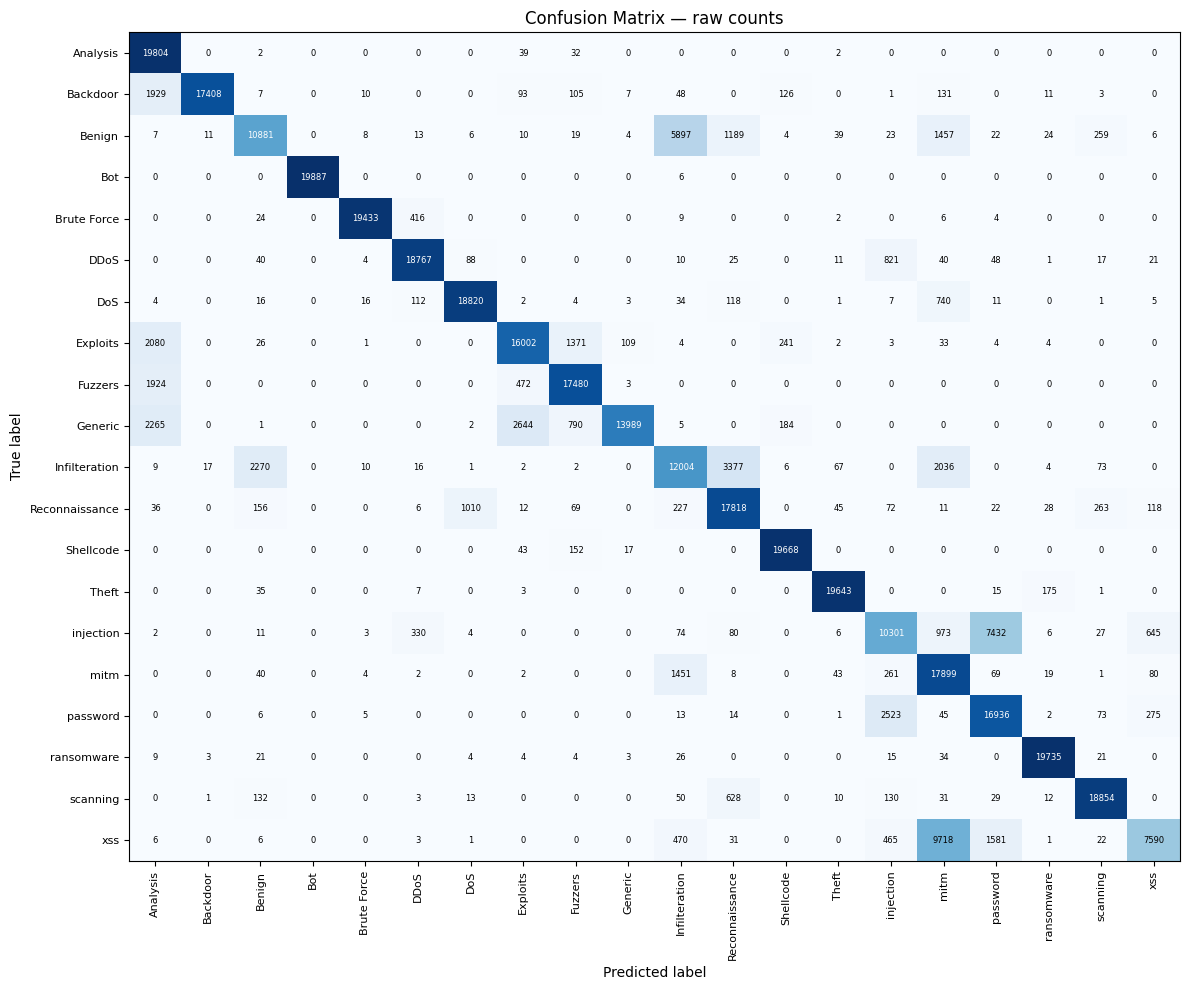

Saved normalized confusion matrix to: /home/vituser23/Downloads/ProtoNet_processed_40M/confusion_matrix_normalized.png


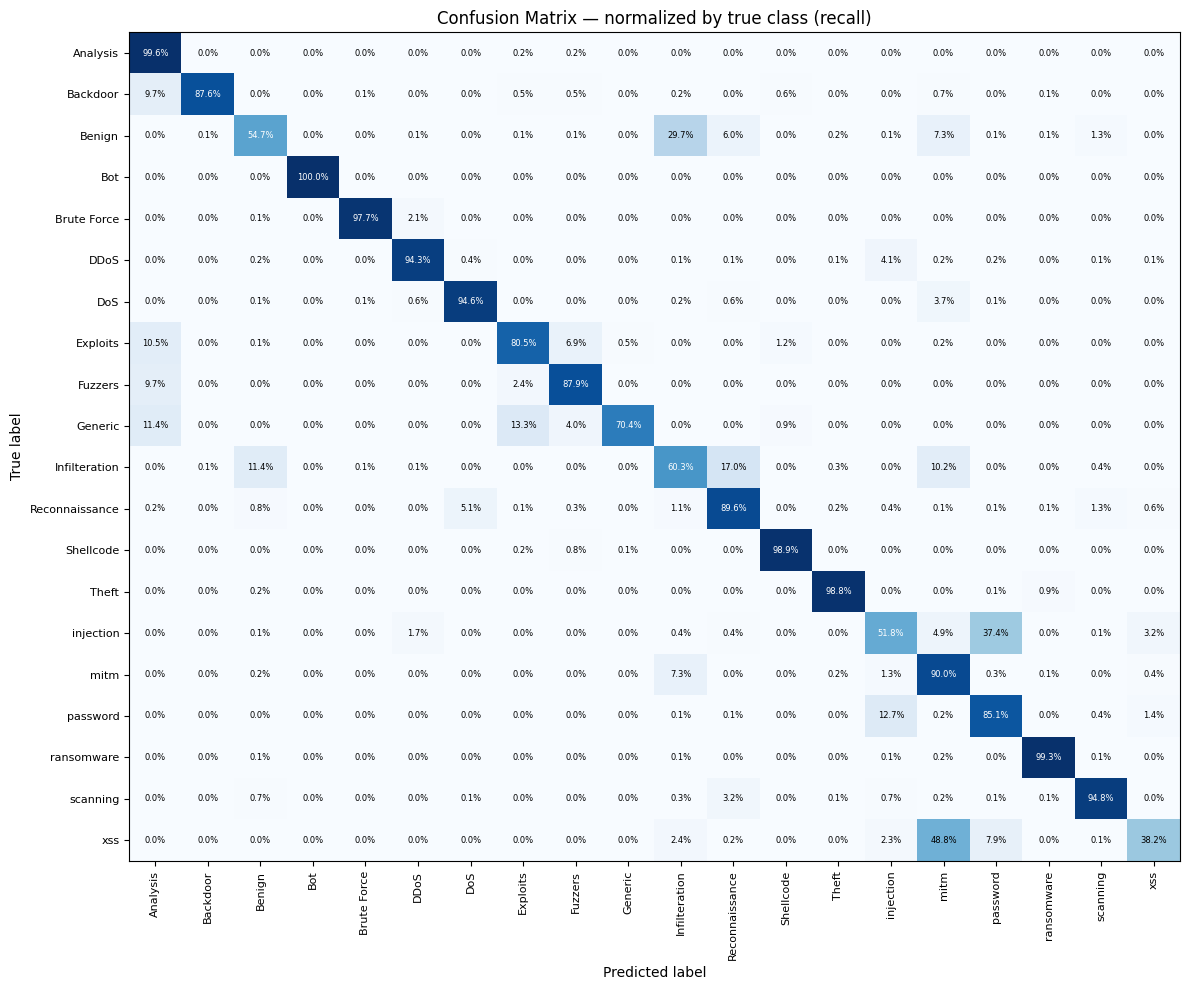


Confusion matrix (raw counts) array:
 [[19804     0     2     0     0     0     0    39    32     0     0     0
      0     2     0     0     0     0     0     0]
 [ 1929 17408     7     0    10     0     0    93   105     7    48     0
    126     0     1   131     0    11     3     0]
 [    7    11 10881     0     8    13     6    10    19     4  5897  1189
      4    39    23  1457    22    24   259     6]
 [    0     0     0 19887     0     0     0     0     0     0     6     0
      0     0     0     0     0     0     0     0]
 [    0     0    24     0 19433   416     0     0     0     0     9     0
      0     2     0     6     4     0     0     0]
 [    0     0    40     0     4 18767    88     0     0     0    10    25
      0    11   821    40    48     1    17    21]
 [    4     0    16     0    16   112 18820     2     4     3    34   118
      0     1     7   740    11     0     1     5]
 [ 2080     0    26     0     1     0     0 16002  1371   109     4     0
    241     

In [ ]:
# Cell 3 — Load model + centroids and evaluate

import os
import json
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import Counter
import pandas as pd

SAVE_DIR = "/home/vituser23/Downloads/ProtoNet_processed_40M"
FEATURES_PATH = os.path.join(SAVE_DIR, "features_resampled.npy")
TARGET_PATH   = os.path.join(SAVE_DIR, "target_resampled.npy")
LABEL_MAP_PATH = os.path.join(SAVE_DIR, "label_mapping.json")

SEED = 42
TEST_SPLIT = 0.2
VAL_RATIO = 0.2

BATCH_SIZE = 512
NUM_WORKERS = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPS = 1e-10

print("Device:", DEVICE)
print("Looking for artifacts in:", SAVE_DIR)

fusion_model_file = os.path.join(SAVE_DIR, "euc_protodemon.pt")
fusion_centroid_file = os.path.join(SAVE_DIR, "euc_final_centroids.pt")
basic_model_file  = os.path.join(SAVE_DIR, "protodemon.pt")
basic_centroid_file = os.path.join(SAVE_DIR, "final_centroids.pt")

if os.path.exists(fusion_model_file) and os.path.exists(fusion_centroid_file):
    model_choice = "fusion"
    model_path = fusion_model_file
    centroid_path = fusion_centroid_file
    meta_path = os.path.join(SAVE_DIR, "euc_protodemon_meta.json")
elif os.path.exists(basic_model_file) and os.path.exists(basic_centroid_file):
    model_choice = "basic"
    model_path = basic_model_file
    centroid_path = basic_centroid_file
    meta_path = os.path.join(SAVE_DIR, "protodemon_meta.json")
else:
    if os.path.exists("euc_protodemon.pt") and os.path.exists("euc_final_centroids.pt"):
        model_choice = "fusion"
        model_path = "euc_protodemon.pt"
        centroid_path = "euc_final_centroids.pt"
        meta_path = "euc_protodemon_meta.json"
    elif os.path.exists("protodemon.pt") and os.path.exists("final_centroids.pt"):
        model_choice = "basic"
        model_path = "protodemon.pt"
        centroid_path = "final_centroids.pt"
        meta_path = "protodemon_meta.json"
    else:
        raise FileNotFoundError("No model + centroid artifacts found. Run training cells first or place artifacts in SAVE_DIR.")

print(f"Selected model choice: {model_choice}")
print("Model file:", model_path)
print("Centroid file:", centroid_path)

def safe_torch_load(path, map_location=None):
    try:
        return torch.load(path, map_location=map_location)
    except Exception:
        import torch.serialization, numpy as _npy
        torch.serialization.add_safe_globals([_npy.core.multiarray.scalar])
        return torch.load(path, map_location=map_location)

def min_max_normalize_per_sample(dist_mat, eps=1e-8):
    min_vals = dist_mat.min(dim=1, keepdim=True)[0]
    max_vals = dist_mat.max(dim=1, keepdim=True)[0]
    return (dist_mat - min_vals) / (max_vals - min_vals + eps)

class ProtoNetV2(nn.Module):
    def __init__(self, input_dim, hid_dim=256, z_dim=128, dropout=0.5):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hid_dim),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(hid_dim),
            nn.Dropout(dropout),
            nn.Linear(hid_dim, hid_dim // 2),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(hid_dim // 2),
            nn.Dropout(dropout),
            nn.Linear(hid_dim // 2, z_dim)
        )
    def forward(self, x):
        return self.encoder(x)

class FusionProtoNet(nn.Module):
    def __init__(self, input_dim, hid_dim=256, z_dim=128, dropout=0.5, init_alpha_logit=0.8473):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hid_dim),
            nn.LeakyReLU(inplace=True),
            nn.BatchNorm1d(hid_dim),
            nn.Dropout(dropout),
            nn.Linear(hid_dim, hid_dim // 2),
            nn.LeakyReLU(inplace=True),
            nn.BatchNorm1d(hid_dim // 2),
            nn.Dropout(dropout),
            nn.Linear(hid_dim // 2, z_dim)
        )
        self.alpha_param = nn.Parameter(torch.tensor(init_alpha_logit, dtype=torch.float32))
    def forward(self, x):
        return self.encoder(x)

X = np.load(FEATURES_PATH)
y = np.load(TARGET_PATH).astype(np.int64)
with open(LABEL_MAP_PATH, "r") as fh:
    label_map = json.load(fh)
inv_label_map = {int(v): str(k) for k, v in label_map.items()}

print("Loaded features:", X.shape, "labels:", y.shape, "num classes:", len(inv_label_map))

if 'test_loader' in globals():
    print("Using existing test_loader from session.")
    test_loader = globals()['test_loader']

    try:
        _, y_test_arr = next(iter(test_loader))
    except Exception:
        y_test_arr = None
else:
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=TEST_SPLIT, random_state=SEED, stratify=y)
    val_size_rel = VAL_RATIO / (1.0 - TEST_SPLIT)

    class PlainArrayDataset(Dataset):
        def __init__(self, X_np, y_np):
            self.X = torch.from_numpy(X_np.astype(np.float32))
            self.y = torch.from_numpy(y_np.astype(np.int64))
        def __len__(self):
            return len(self.y)
        def __getitem__(self, idx):
            return self.X[idx], self.y[idx]

    test_ds = PlainArrayDataset(X_test, y_test)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    print("Constructed test_loader with", len(test_ds), "samples.")

input_dim = X.shape[1]
hid_dim = 256
z_dim = 128

if os.path.exists(meta_path):
    try:
        with open(meta_path, "r") as fh:
            meta = json.load(fh)
            input_dim = int(meta.get("input_dim", input_dim))
            hid_dim = int(meta.get("hid_dim", hid_dim))
            z_dim = int(meta.get("z_dim", z_dim))
            print("Read dims from meta:", input_dim, hid_dim, z_dim)
    except Exception:
        pass

if model_choice == "fusion":
    model = FusionProtoNet(input_dim=input_dim, hid_dim=hid_dim, z_dim=z_dim).to(DEVICE)
else:
    model = ProtoNetV2(input_dim=input_dim, hid_dim=hid_dim, z_dim=z_dim).to(DEVICE)

state = safe_torch_load(model_path, map_location=DEVICE)
if isinstance(state, dict) and all(k.startswith('module') or k in model.state_dict() for k in state.keys()):
    try:
        model.load_state_dict(state)
    except Exception:
        if 'model_state_dict' in state:
            model.load_state_dict(state['model_state_dict'])
        elif 'state_dict' in state:
            model.load_state_dict(state['state_dict'])
        else:
            filtered = {k: v for k, v in state.items() if k in model.state_dict()}
            model.load_state_dict(filtered)
else:
    try:
        model.load_state_dict(state)
    except Exception as e:
        raise RuntimeError(f"Couldn't load model state: {e}")

model.to(DEVICE)
model.eval()
print("Loaded model and moved to device.")

centroids = safe_torch_load(centroid_path, map_location=DEVICE)
if not isinstance(centroids, torch.Tensor):
    try:
        centroids = torch.tensor(np.asarray(centroids), dtype=torch.float32)
    except Exception:
        raise RuntimeError("Could not coerce centroids into a torch tensor.")
centroids = centroids.to(DEVICE)
print("Loaded centroids shape:", tuple(centroids.shape))

all_true = []
all_pred = []
all_conf = []
all_proto_conf = []
all_xgb_conf = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        emb = model(xb)
        if model_choice == "fusion":
            d_e = torch.cdist(emb, centroids)

            emb_norm = emb / (emb.norm(dim=1, keepdim=True) + 1e-8)
            cent_norm = centroids / (centroids.norm(dim=1, keepdim=True) + 1e-8)
            d_c = 1.0 - torch.matmul(emb_norm, cent_norm.t())
            d_e_norm = min_max_normalize_per_sample(d_e, eps=1e-8)
            d_c_norm = min_max_normalize_per_sample(d_c, eps=1e-8)
            alpha = torch.sigmoid(model.alpha_param)
            d_fused = alpha * d_e_norm + (1.0 - alpha) * d_c_norm
            logits = -d_fused
            probs = F.softmax(logits, dim=1)
            conf, pred = torch.max(probs, dim=1)
            all_proto_conf.extend(probs.max(dim=1)[0].cpu().numpy().tolist())
        else:
            dists = torch.cdist(emb, centroids) + EPS
            logits = -dists
            probs = F.softmax(logits, dim=1)
            conf, pred = torch.max(probs, dim=1)
            all_proto_conf.extend(probs.max(dim=1)[0].cpu().numpy().tolist())

        all_true.extend(yb.cpu().numpy().tolist())
        all_pred.extend(pred.cpu().numpy().tolist())
        all_conf.extend(conf.cpu().numpy().tolist())

acc = accuracy_score(all_true, all_pred)
print(f"\nOverall test accuracy: {acc:.4f}\n")

print("Classification report (by class index):")
print(classification_report(all_true, all_pred, digits=4, zero_division=0))

cm = confusion_matrix(all_true, all_pred)
print("Confusion matrix shape:", cm.shape)

import matplotlib.pyplot as plt
import numpy as np
import os

if 'cm' not in globals():
    cm = confusion_matrix(all_true, all_pred)

labels = [inv_label_map.get(i, str(i)) for i in range(cm.shape[0])]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, interpolation='nearest', aspect='auto', cmap="Blues")
ax.set_title("Confusion Matrix — raw counts")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticklabels(labels, fontsize=8)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                fontsize=6,
                color="white" if cm[i, j] > thresh else "black")

fig.tight_layout()
raw_png = os.path.join(SAVE_DIR, "confusion_matrix_raw.png")
fig.savefig(raw_png, dpi=150, bbox_inches='tight')
print("Saved raw confusion matrix to:", raw_png)
plt.show()

row_sums = cm.sum(axis=1, keepdims=True).clip(min=1)
cm_norm = cm.astype(np.float32) / row_sums

fig2, ax2 = plt.subplots(figsize=(12, 10))
im2 = ax2.imshow(cm_norm, interpolation='nearest', aspect='auto', cmap="Blues")
ax2.set_title("Confusion Matrix — normalized by true class (recall)")
ax2.set_xlabel("Predicted label")
ax2.set_ylabel("True label")
ax2.set_xticks(np.arange(len(labels)))
ax2.set_yticks(np.arange(len(labels)))
ax2.set_xticklabels(labels, rotation=90, fontsize=8)
ax2.set_yticklabels(labels, fontsize=8)

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        val = cm_norm[i, j] * 100.0
        ax2.text(j, i, f"{val:.1f}%",
                 ha="center", va="center",
                 fontsize=6,
                 color="white" if cm_norm[i, j] > 0.5 else "black")

fig2.tight_layout()
norm_png = os.path.join(SAVE_DIR, "confusion_matrix_normalized.png")
fig2.savefig(norm_png, dpi=150, bbox_inches='tight')
print("Saved normalized confusion matrix to:", norm_png)
plt.show()

print("\nConfusion matrix (raw counts) array:\n", cm)
print("\nConfusion matrix (row-normalized) array:\n", np.round(cm_norm, 4))


support_counts = Counter(all_true)
print("\nSupport counts (test set):")
for cls_idx, cnt in sorted(support_counts.items()):
    cls_name = inv_label_map.get(int(cls_idx), str(cls_idx))
    print(f"  {cls_idx} ({cls_name}): {cnt}")

out_df = pd.DataFrame({
    "true_label": all_true,
    "pred_label": all_pred,
    "pred_confidence": all_conf
})
out_csv = os.path.join(SAVE_DIR, "cell3_evaluation_predictions.csv")
out_df.to_csv(out_csv, index=False)
print(f"\nSaved per-sample predictions to: {out_csv}")

summary = {
    "model_choice": model_choice,
    "model_path": model_path,
    "centroid_path": centroid_path,
    "test_accuracy": float(acc),
    "num_test_samples": int(len(all_true)),
    "num_classes": int(len(inv_label_map))
}
with open(os.path.join(SAVE_DIR, "cell3_evaluation_summary.json"), "w") as fh:
    json.dump(summary, fh, indent=2)
print("Saved evaluation summary JSON to SAVE_DIR.")

print("\nCell 3 evaluation complete.")


Model type: fusion
Centroids path: /home/vituser23/Downloads/ProtoNet_processed_40M/euc_final_centroids.pt
Centroids shape: (20, 128) alpha_pre_read: 3.618338450905867e-05
Computing val embeddings by loading checkpoint and re-splitting features/targets from disk...


/tmp/ipykernel_4062181/4090867527.py:139: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  alpha_sigmoid = float(torch.sigmoid(torch.tensor(ckpt['alpha_param'])).item())


Computed val_embs from disk-split: (397728, 128)
Validation size: 397728; dmin min/med/max = 0.0000/0.0000/0.0000
proto_maxprob min/med/max = 0.0744/0.1222/0.1249
Calibration stats: {'tau_dist_percentile': 100.0, 'p_thresh_percentile': 2.0, 'tau_dist': 3.618338450905867e-05, 'p_thresh': 0.10542055070400239, 'tau_dist_roc_approx': None}
Chosen thresholds: {'tau_dist': 3.618338450905867e-05, 'p_thresh': 0.10542055070400239}
Rejection rate: 0.0200
Accuracy on accepted samples: 0.8486
Accepted F1 (macro): 0.8420
Saved diagnostic plot to: /home/vituser23/Downloads/ProtoNet_processed_40M/dmin_known_vs_ood.png


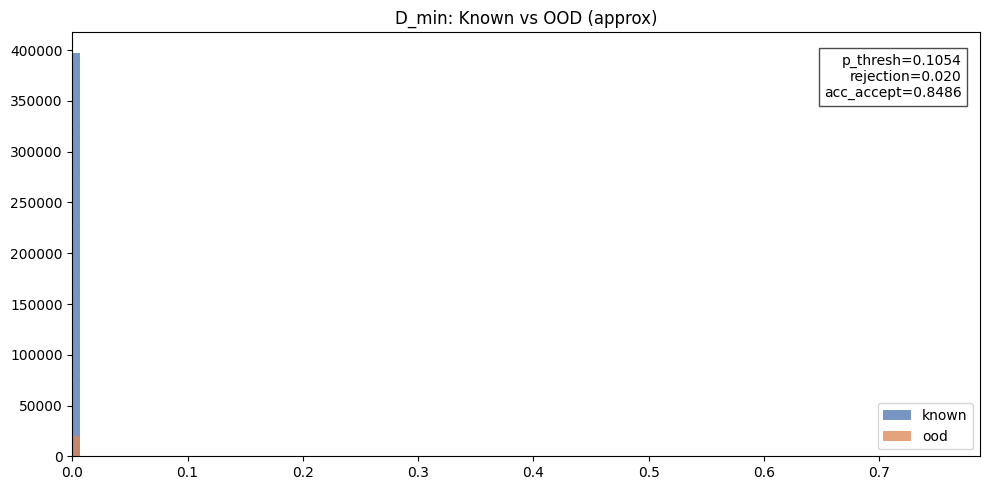

Saved thresholds to: /home/vituser23/Downloads/ProtoNet_processed_40M/rejection_thresholds.pt /home/vituser23/Downloads/ProtoNet_processed_40M/rejection_thresholds.json


In [ ]:

# Cell 6 — Rejection mechanism

import os, json, math, tempfile, shutil, time
from collections import OrderedDict
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt

SAVE_DIR = "/home/vituser23/Downloads/ProtoNet_processed_40M"
VAL_EMB_PATH = os.path.join(SAVE_DIR, "val_embs.npy")
VAL_LABELS_PATH = os.path.join(SAVE_DIR, "val_labels.npy")
ART_MODEL_FUSION = os.path.join(SAVE_DIR, "euc_protodemon.pt")
ART_CENTROIDS_FUSION = os.path.join(SAVE_DIR, "euc_final_centroids.pt")
ART_MODEL_BASIC = os.path.join(SAVE_DIR, "protodemon.pt")
ART_CENTROIDS_BASIC = os.path.join(SAVE_DIR, "final_centroids.pt")
REJ_THRESH_PT = os.path.join(SAVE_DIR, "rejection_thresholds.pt")
REJ_THRESH_JSON = os.path.join(SAVE_DIR, "rejection_thresholds.json")
PLOT_PNG = os.path.join(SAVE_DIR, "dmin_known_vs_ood.png")

FEATURES_PATH = os.path.join(SAVE_DIR, "features_resampled.npy")
TARGET_PATH = os.path.join(SAVE_DIR, "target_resampled.npy")
LABEL_MAP_PATH = os.path.join(SAVE_DIR, "label_mapping.json")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 1024
SEED = 42
TARGET_COVERAGE = 0.98
GRID_TAU_PCTS = np.linspace(90, 100, 21)
GRID_P_PCTS   = np.linspace(0, 20, 21)
VERBOSE = True

np.random.seed(SEED)
torch.manual_seed(SEED)

def atomic_save(obj, dst_path):
    dst_dir = os.path.dirname(os.path.abspath(dst_path)) or "."
    os.makedirs(dst_dir, exist_ok=True)
    fd, tmp_path = tempfile.mkstemp(prefix=".tmp_rej_", dir=dst_dir)
    os.close(fd)
    try:
        with open(tmp_path, "wb") as f:
            torch.save(obj, f)
        try:
            os.replace(tmp_path, dst_path)
        except Exception:
            shutil.move(tmp_path, dst_path)
    finally:
        if os.path.exists(tmp_path):
            try: os.remove(tmp_path)
            except Exception: pass

def euclidean_distance_matrix(x, centroids):
    return torch.cdist(x, centroids)

def cosine_distance_matrix(x, centroids, eps=1e-8):
    x_norm = x / (x.norm(dim=1, keepdim=True) + eps)
    c_norm = centroids / (centroids.norm(dim=1, keepdim=True) + eps)
    sim = torch.matmul(x_norm, c_norm.t())
    return 1.0 - sim

def min_max_normalize_per_sample(dist_mat, eps=1e-8):
    min_vals = dist_mat.min(dim=1, keepdim=True)[0]
    max_vals = dist_mat.max(dim=1, keepdim=True)[0]
    return (dist_mat - min_vals) / (max_vals - min_vals + eps)

import torch.nn as nn
class ProtoNetV2(nn.Module):
    def __init__(self, input_dim, hid_dim=256, z_dim=128, dropout=0.5):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hid_dim),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(hid_dim),
            nn.Dropout(dropout),
            nn.Linear(hid_dim, hid_dim // 2),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(hid_dim // 2),
            nn.Dropout(dropout),
            nn.Linear(hid_dim // 2, z_dim)
        )
    def forward(self, x): return self.encoder(x)

class FusionProtoNet(nn.Module):
    def __init__(self, input_dim, hid_dim=256, z_dim=128, dropout=0.5, init_alpha_logit=0.8473):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hid_dim),
            nn.LeakyReLU(inplace=True),
            nn.BatchNorm1d(hid_dim),
            nn.Dropout(dropout),
            nn.Linear(hid_dim, hid_dim // 2),
            nn.LeakyReLU(inplace=True),
            nn.BatchNorm1d(hid_dim // 2),
            nn.Dropout(dropout),
            nn.Linear(hid_dim // 2, z_dim)
        )
        self.alpha_param = nn.Parameter(torch.tensor(init_alpha_logit, dtype=torch.float32))
    def forward(self, x): return self.encoder(x)

if os.path.exists(ART_MODEL_FUSION) and os.path.exists(ART_CENTROIDS_FUSION):
    model_path = ART_MODEL_FUSION; centroid_path = ART_CENTROIDS_FUSION; model_type = "fusion"
elif os.path.exists(ART_MODEL_BASIC) and os.path.exists(ART_CENTROIDS_BASIC):
    model_path = ART_MODEL_BASIC; centroid_path = ART_CENTROIDS_BASIC; model_type = "basic"
else:
    raise FileNotFoundError("No model+centroids in SAVE_DIR; run training cells first.")

if VERBOSE:
    print("Model type:", model_type)
    print("Centroids path:", centroid_path)

centroids = torch.load(centroid_path, map_location=DEVICE)
if not isinstance(centroids, torch.Tensor):
    centroids = torch.tensor(np.asarray(centroids), dtype=torch.float32)
centroids = centroids.to(DEVICE)
z_dim = centroids.shape[1]

alpha_sigmoid = None
if model_type == "fusion":
    try:
        ckpt = torch.load(model_path, map_location='cpu')
        if isinstance(ckpt, dict):
            if 'alpha_param' in ckpt:
                alpha_sigmoid = float(torch.sigmoid(torch.tensor(ckpt['alpha_param'])).item())
            else:
                for key in ('model_state_dict','state_dict'):
                    if key in ckpt and isinstance(ckpt[key], dict):
                        for k,v in ckpt[key].items():
                            if 'alpha_param' in k:
                                alpha_sigmoid = float(torch.sigmoid(v).item()); break
                        if alpha_sigmoid is not None: break
    except Exception:
        alpha_sigmoid = None

if VERBOSE:
    print("Centroids shape:", tuple(centroids.shape), "alpha_pre_read:", alpha_sigmoid)

val_embs = None; y_val = None

if os.path.exists(VAL_EMB_PATH):
    val_embs = np.load(VAL_EMB_PATH).astype(np.float32)
    if os.path.exists(VAL_LABELS_PATH):
        y_val = np.load(VAL_LABELS_PATH).astype(np.int64)
    if VERBOSE:
        print("Loaded precomputed val_embs:", VAL_EMB_PATH, "shape=", val_embs.shape)

if val_embs is None:
    if 'val_loader' in globals() and 'model' in globals() and globals()['model'] is not None:
        if VERBOSE: print("Computing val embeddings with in-session model + val_loader...")
        model_local = globals()['model']; model_local.to(DEVICE); model_local.eval()
        embs=[]; labs=[]
        with torch.no_grad():
            for xb, yb in globals()['val_loader']:
                xb = xb.to(DEVICE)
                e = model_local(xb).cpu().numpy()
                embs.append(e); labs.append(yb.numpy())
        if len(embs)==0: raise RuntimeError("val_loader yielded no batches.")
        val_embs = np.concatenate(embs, axis=0).astype(np.float32)
        y_val = np.concatenate(labs, axis=0).astype(np.int64)
        if VERBOSE: print("Computed val_embs shape:", val_embs.shape)

if val_embs is None:
    if os.path.exists(FEATURES_PATH) and os.path.exists(TARGET_PATH) and os.path.exists(model_path):
        if VERBOSE: print("Computing val embeddings by loading checkpoint and re-splitting features/targets from disk...")
        X_all = np.load(FEATURES_PATH).astype(np.float32)
        y_all = np.load(TARGET_PATH).astype(np.int64)
        X_temp, X_test, y_temp, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all)
        val_size_rel = 0.2 / (1.0 - 0.2)
        X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
            X_temp, y_temp, test_size=val_size_rel, random_state=SEED, stratify=y_temp
        )
        input_dim = X_all.shape[1]
        if model_type == "fusion":
            model_local = FusionProtoNet(input_dim=input_dim, hid_dim=256, z_dim=z_dim).to(DEVICE)
        else:
            model_local = ProtoNetV2(input_dim=input_dim, hid_dim=256, z_dim=z_dim).to(DEVICE)

        ckpt = torch.load(model_path, map_location='cpu')
        if isinstance(ckpt, dict):
            if 'model_state_dict' in ckpt: state_dict = ckpt['model_state_dict']
            elif 'state_dict' in ckpt: state_dict = ckpt['state_dict']
            else: state_dict = ckpt

            new_state = {}
            mkeys = model_local.state_dict().keys()
            for k,v in state_dict.items():
                kk = k[7:] if k.startswith("module.") and k[7:] in mkeys else k
                if kk in mkeys:
                    new_state[kk]=v
            model_local.load_state_dict(new_state, strict=False)
        else:
            model_local.load_state_dict(ckpt, strict=False)
        model_local.eval()

        val_embs_list=[]
        with torch.no_grad():
            dl = DataLoader(torch.from_numpy(X_val_split.astype(np.float32)), batch_size=BATCH_SIZE)
            for xb in dl:
                xb = xb.to(DEVICE)
                emb = model_local(xb).cpu().numpy()
                val_embs_list.append(emb)
        val_embs = np.concatenate(val_embs_list, axis=0).astype(np.float32)
        y_val = y_val_split
        if VERBOSE: print("Computed val_embs from disk-split:", val_embs.shape)
    else:
        raise RuntimeError("Cannot obtain validation embeddings. Provide val_embs.npy or make val_loader/model available or ensure features/targets+checkpoint exist.")

if val_embs is None or y_val is None:
    raise RuntimeError("Validation embeddings or labels could not be obtained.")

val_embs_t = torch.tensor(val_embs, dtype=torch.float32).to(DEVICE)
y_val = np.asarray(y_val, dtype=np.int64)

if alpha_sigmoid is None:
    try:
        if 'model_local' in locals() and hasattr(model_local, 'alpha_param'):
            alpha_sigmoid = float(torch.sigmoid(model_local.alpha_param).detach().cpu().item())
        elif 'model' in globals() and globals()['model'] is not None and hasattr(globals()['model'], 'alpha_param'):
            alpha_sigmoid = float(torch.sigmoid(globals()['model'].alpha_param).detach().cpu().item())
    except Exception:
        alpha_sigmoid = None
if alpha_sigmoid is None:
    alpha_sigmoid = 1.0

with torch.no_grad():
    cent_t = centroids.clone().to(DEVICE)
    d_e_all = euclidean_distance_matrix(val_embs_t, cent_t)
    d_c_all = cosine_distance_matrix(val_embs_t, cent_t)
    d_e_norm = min_max_normalize_per_sample(d_e_all)
    d_c_norm = min_max_normalize_per_sample(d_c_all)
    alpha = float(alpha_sigmoid)
    d_fused_all = alpha * d_e_norm + (1.0 - alpha) * d_c_norm
    logits = -d_fused_all
    Pproto_val = F.softmax(logits, dim=1).cpu().numpy()
    proto_maxprob_val = Pproto_val.max(axis=1)
    dmin_val = d_fused_all.min(dim=1).values.cpu().numpy()

Nval = len(dmin_val)
if VERBOSE:
    print(f"Validation size: {Nval}; dmin min/med/max = {dmin_val.min():.4f}/{np.median(dmin_val):.4f}/{dmin_val.max():.4f}")
    print(f"proto_maxprob min/med/max = {proto_maxprob_val.min():.4f}/{np.median(proto_maxprob_val):.4f}/{proto_maxprob_val.max():.4f}")

emb_mean = val_embs.mean(axis=0)
emb_std  = val_embs.std(axis=0) + 1e-6
np.random.seed(SEED+7)
ood1 = np.random.normal(loc=emb_mean, scale=emb_std * 0.5, size=(min(20000, Nval), emb_mean.shape[0])).astype(np.float32)
ood2 = np.random.normal(loc=emb_mean + 2.5*emb_std, scale=emb_std*1.0, size=(min(20000, Nval), emb_mean.shape[0])).astype(np.float32)
# compute dmin for both and pick the one with larger median (more OOD)
with torch.no_grad():
    ood1_t = torch.from_numpy(ood1).to(DEVICE)
    ood2_t = torch.from_numpy(ood2).to(DEVICE)
    d_e_o1 = euclidean_distance_matrix(ood1_t, cent_t); d_c_o1 = cosine_distance_matrix(ood1_t, cent_t)
    d_e_o2 = euclidean_distance_matrix(ood2_t, cent_t); d_c_o2 = cosine_distance_matrix(ood2_t, cent_t)
    d_o1 = (alpha * min_max_normalize_per_sample(d_e_o1) + (1.0-alpha)*min_max_normalize_per_sample(d_c_o1)).min(dim=1).values.cpu().numpy()
    d_o2 = (alpha * min_max_normalize_per_sample(d_e_o2) + (1.0-alpha)*min_max_normalize_per_sample(d_c_o2)).min(dim=1).values.cpu().numpy()

ood_dmin = d_o2 if np.median(d_o2) > np.median(d_o1) else d_o1

tau_candidates = np.percentile(dmin_val, GRID_TAU_PCTS)
p_candidates = np.percentile(proto_maxprob_val, GRID_P_PCTS)
preds_all = Pproto_val.argmax(axis=1)

best_conf = {'tau_dist':None,'p_thresh':None,'accepted_acc':-1.0,'coverage':0.0,'score':-1.0,'tau_pct':None,'p_pct':None}
for i,tau in enumerate(tau_candidates):
    for j,pth in enumerate(p_candidates):
        mask = (dmin_val <= float(tau)) & (proto_maxprob_val >= float(pth))
        coverage = float(mask.mean())
        if coverage == 0: continue
        acc = float((preds_all[mask] == y_val[mask]).mean()) if mask.sum()>0 else float('nan')
        meets_cov = coverage >= TARGET_COVERAGE
        score = acc * (1.0 + max(0.0, (coverage - TARGET_COVERAGE)) * 0.5) if meets_cov else acc * (coverage / TARGET_COVERAGE)
        if np.isnan(score): continue
        if score > best_conf['score']:
            best_conf.update({'tau_dist':float(tau),'p_thresh':float(pth),'accepted_acc':float(acc),'coverage':float(coverage),'score':float(score),'tau_pct':float(GRID_TAU_PCTS[i]),'p_pct':float(GRID_P_PCTS[j])})

if best_conf['tau_dist'] is None:
    best_conf['tau_dist'] = float(np.percentile(dmin_val, 98))
    best_conf['p_thresh']  = float(np.percentile(proto_maxprob_val, 5))
    mask = (dmin_val <= best_conf['tau_dist']) & (proto_maxprob_val >= best_conf['p_thresh'])
    best_conf['coverage'] = float(mask.mean())
    best_conf['accepted_acc'] = float((preds_all[mask] == y_val[mask]).mean()) if mask.sum()>0 else float('nan')
    best_conf['score'] = best_conf['accepted_acc']

tau_dist = float(best_conf['tau_dist'])
p_thresh = float(best_conf['p_thresh'])
accepted_mask = (dmin_val <= tau_dist) & (proto_maxprob_val >= p_thresh)
coverage = float(accepted_mask.mean())
rejection_rate = 1.0 - coverage
accepted_preds = preds_all[accepted_mask]
accepted_trues = y_val[accepted_mask]
acc_accepted = float((accepted_preds == accepted_trues).mean()) if accepted_trues.size>0 else float('nan')
f1_accepted = float(f1_score(accepted_trues, accepted_preds, average='macro')) if accepted_trues.size>0 else float('nan')

cal_stats = {
    'tau_dist_percentile': best_conf.get('tau_pct'),
    'p_thresh_percentile': best_conf.get('p_pct'),
    'tau_dist': tau_dist,
    'p_thresh': p_thresh,
    'tau_dist_roc_approx': None
}
print("Calibration stats:", cal_stats)
print("Chosen thresholds:", {'tau_dist': tau_dist, 'p_thresh': p_thresh})
print(f"Rejection rate: {rejection_rate:.4f}")
print(f"Accuracy on accepted samples: {acc_accepted:.4f}")
print(f"Accepted F1 (macro): {f1_accepted:.4f}")

plt.style.use('default')
fig, ax = plt.subplots(figsize=(10,5))
bins = np.linspace(0.0, max(dmin_val.max(), ood_dmin.max(), 0.75), 120)
ax.hist(dmin_val, bins=bins, alpha=0.75, label='known', density=False, color='#4c72b0')
ax.hist(ood_dmin, bins=bins, alpha=0.75, label='ood', density=False, color='#dd8452')
ax.set_xlim(left=0.0)
ax.set_title("D_min: Known vs OOD (approx)")
ax.legend()
ax.axvline(tau_dist, color='k', linestyle='--', label=f"tau_dist={tau_dist:.4f}")
ax.text(0.98, 0.95, f"p_thresh={p_thresh:.4f}\nrejection={rejection_rate:.3f}\nacc_accept={acc_accepted:.4f}", transform=ax.transAxes, ha='right', va='top', bbox=dict(facecolor='white', alpha=0.7))
fig.tight_layout()
fig.savefig(PLOT_PNG, dpi=150, bbox_inches='tight')
print("Saved diagnostic plot to:", PLOT_PNG)
plt.show()

thresholds_obj = {
    'thresholds': {'tau_dist': tau_dist, 'p_thresh': p_thresh, 'tau_pct': best_conf.get('tau_pct'), 'p_pct': best_conf.get('p_pct')},
    'meta': {'model_type': model_type, 'alpha': float(alpha), 'val_size': int(Nval), 'created_at': time.strftime("%Y-%m-%d %H:%M:%S") },
    'validation_stats': {'accepted_acc': acc_accepted, 'coverage': coverage, 'rejection_rate': rejection_rate, 'accepted_f1_macro': f1_accepted}
}
atomic_save(thresholds_obj, REJ_THRESH_PT)
with open(REJ_THRESH_JSON, "w") as fh:
    json.dump(thresholds_obj, fh, indent=2)

print("Saved thresholds to:", REJ_THRESH_PT, REJ_THRESH_JSON)


In [ ]:
# Cell 9 — XGBoost on ProtoNet embeddings

import os, json, time
from collections import OrderedDict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# CONFIG
SAVE_DIR = "/home/vituser23/Downloads/ProtoNet_processed_40M"
FEATURES_PATH = os.path.join(SAVE_DIR, "features_resampled.npy")
TARGET_PATH   = os.path.join(SAVE_DIR, "target_resampled.npy")
LABEL_MAP_PATH = os.path.join(SAVE_DIR, "label_mapping.json")
MODEL_FUSION = os.path.join(SAVE_DIR, "euc_protodemon.pt")
MODEL_BASIC  = os.path.join(SAVE_DIR, "protodemon.pt")
EMB_TRAIN_OUT = os.path.join(SAVE_DIR, "proto_emb_train.npy")
EMB_VAL_OUT   = os.path.join(SAVE_DIR, "proto_emb_val.npy")
EMB_TEST_OUT  = os.path.join(SAVE_DIR, "proto_emb_test.npy")
XGB_MODEL_OUT = os.path.join(SAVE_DIR, "xgb_on_proto_embeddings.joblib")
XGB_META_OUT  = os.path.join(SAVE_DIR, "xgb_on_proto_meta.json")
PRED_CSV_OUT  = os.path.join(SAVE_DIR, "cell9_predictions_test.csv")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
BATCH_SIZE = 2048
TEST_SPLIT = 0.2
VAL_RATIO = 0.2
RANDOM_STATE = SEED

np.random.seed(SEED)
torch.manual_seed(SEED)

print("Device:", DEVICE)
os.makedirs(SAVE_DIR, exist_ok=True)

class ProtoNetV2(nn.Module):
    def __init__(self, input_dim, hid_dim=256, z_dim=128, dropout=0.5):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hid_dim),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(hid_dim),
            nn.Dropout(dropout),
            nn.Linear(hid_dim, hid_dim // 2),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(hid_dim // 2),
            nn.Dropout(dropout),
            nn.Linear(hid_dim // 2, z_dim)
        )
    def forward(self, x): return self.encoder(x)

class FusionProtoNet(nn.Module):
    def __init__(self, input_dim, hid_dim=256, z_dim=128, dropout=0.5, init_alpha_logit=0.8473):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hid_dim),
            nn.LeakyReLU(inplace=True),
            nn.BatchNorm1d(hid_dim),
            nn.Dropout(dropout),
            nn.Linear(hid_dim, hid_dim // 2),
            nn.LeakyReLU(inplace=True),
            nn.BatchNorm1d(hid_dim // 2),
            nn.Dropout(dropout),
            nn.Linear(hid_dim // 2, z_dim)
        )
        self.alpha_param = nn.Parameter(torch.tensor(init_alpha_logit, dtype=torch.float32))
    def forward(self, x): return self.encoder(x)

def compute_embeddings_from_model(model, X_np, batch_size=2048, device=DEVICE):
    model.eval()
    embs = []
    with torch.no_grad():
        for i in range(0, X_np.shape[0], batch_size):
            xb = torch.from_numpy(X_np[i:i+batch_size].astype(np.float32)).to(device)
            e = model(xb).cpu().numpy()
            embs.append(e)
    return np.concatenate(embs, axis=0)

if not (os.path.exists(FEATURES_PATH) and os.path.exists(TARGET_PATH)):
    raise FileNotFoundError("features_resampled.npy and target_resampled.npy must exist in SAVE_DIR")

X = np.load(FEATURES_PATH).astype(np.float32)
y = np.load(TARGET_PATH).astype(np.int64)
with open(LABEL_MAP_PATH, "r") as fh:
    label_map = json.load(fh)
inv_label_map = {int(v): str(k) for k,v in label_map.items()}
num_classes = len(inv_label_map)

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=TEST_SPLIT, random_state=SEED, stratify=y)
val_size_rel = VAL_RATIO / (1.0 - TEST_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_size_rel, random_state=SEED, stratify=y_temp)

print("Splits -> train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)

if os.path.exists(MODEL_FUSION):
    model_path = MODEL_FUSION; model_type = "fusion"
elif os.path.exists(MODEL_BASIC):
    model_path = MODEL_BASIC; model_type = "basic"
else:
    raise FileNotFoundError("No model checkpoint found in SAVE_DIR (euc_protodemon.pt or protodemon.pt)")

print("Model type:", model_type, "loading weights from:", model_path)

input_dim = X.shape[1]
for meta_name in ("euc_protodemon_meta.json", "protodemon_meta.json"):
    p = os.path.join(SAVE_DIR, meta_name)
    if os.path.exists(p):
        try:
            with open(p, 'r') as fh: meta = json.load(fh)
            input_dim = int(meta.get("input_dim", input_dim))
            print("Read input_dim from meta:", input_dim)
            break
        except Exception:
            pass

if model_type == "fusion":
    model_local = FusionProtoNet(input_dim=input_dim, hid_dim=256, z_dim=128).to(DEVICE)
else:
    model_local = ProtoNetV2(input_dim=input_dim, hid_dim=256, z_dim=128).to(DEVICE)

ckpt = torch.load(model_path, map_location='cpu')
if isinstance(ckpt, dict):
    if 'model_state_dict' in ckpt:
        st = ckpt['model_state_dict']
    elif 'state_dict' in ckpt:
        st = ckpt['state_dict']
    else:
        st = ckpt
else:
    st = ckpt

model_keys = set(model_local.state_dict().keys())
good_state = {}
for k,v in st.items():
    kk = k[7:] if k.startswith("module.") and k[7:] in model_keys else k
    if kk in model_keys:
        good_state[kk] = v
model_local.load_state_dict(good_state, strict=False)
model_local.to(DEVICE)
model_local.eval()
print("Loaded model_local and ready on device.")

print("Computing embeddings for train / val / test splits (this may take a while)...")
emb_train = compute_embeddings_from_model(model_local, X_train, batch_size=BATCH_SIZE, device=DEVICE)
emb_val   = compute_embeddings_from_model(model_local, X_val, batch_size=BATCH_SIZE, device=DEVICE)
emb_test  = compute_embeddings_from_model(model_local, X_test, batch_size=BATCH_SIZE, device=DEVICE)

print("Embeddings shapes -> train:", emb_train.shape, "val:", emb_val.shape, "test:", emb_test.shape)

np.save(EMB_TRAIN_OUT, emb_train)
np.save(EMB_VAL_OUT, emb_val)
np.save(EMB_TEST_OUT, emb_test)
print("Saved embeddings to:", EMB_TRAIN_OUT, EMB_VAL_OUT, EMB_TEST_OUT)

# Train XGBoost
try:
    import xgboost as xgb
    have_xgb = True
except Exception:
    have_xgb = False

model_meta = {'created_at': time.strftime("%Y-%m-%d %H:%M:%S", time.localtime()),
              'model_type': model_type,
              'xgb_used': have_xgb,
              'num_classes': int(num_classes),
              'n_train': int(emb_train.shape[0]),
              'n_val': int(emb_val.shape[0]),
              'n_test': int(emb_test.shape[0])}

if have_xgb:
    print("Training XGBoost classifier on ProtoNet embeddings (multi:softprob)...")

    dtrain = xgb.DMatrix(emb_train, label=y_train)
    dval   = xgb.DMatrix(emb_val, label=y_val)
    params = {
        'objective': 'multi:softprob',
        'num_class': num_classes,
        'eval_metric': 'mlogloss',
        'eta': 0.1,
        'max_depth': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'seed': SEED,
        'verbosity': 1
    }
    evals = [(dtrain, 'train'), (dval, 'val')]
    bst = xgb.train(params, dtrain, num_boost_round=500, evals=evals, early_stopping_rounds=30, verbose_eval=25)

    joblib.dump(bst, XGB_MODEL_OUT)
    model_meta['xgb_params'] = params
    best_ntree_limit = None
    if hasattr(bst, 'best_ntree_limit') and bst.best_ntree_limit is not None:
        best_ntree_limit = int(bst.best_ntree_limit)
    elif hasattr(bst, 'best_iteration') and bst.best_iteration is not None:
        best_ntree_limit = int(bst.best_iteration + 1)
    model_meta['best_ntree_limit'] = best_ntree_limit
    print("Saved XGBoost model to:", XGB_MODEL_OUT, "best_ntree_limit:", best_ntree_limit)
else:
    from sklearn.ensemble import RandomForestClassifier
    print("xgboost not available — training RandomForestClassifier as fallback.")
    clf = RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=SEED)
    clf.fit(emb_train, y_train)
    joblib.dump(clf, XGB_MODEL_OUT)
    model_meta['fallback'] = 'RandomForest'
    print("Saved fallback classifier to:", XGB_MODEL_OUT)

print("Evaluating classifier on test set...")
if have_xgb:
    dtest = xgb.DMatrix(emb_test)
    probs = None
    try:
        if model_meta.get('best_ntree_limit') is not None:

            end_iter = int(model_meta['best_ntree_limit'])
            probs = bst.predict(dtest, iteration_range=(0, end_iter))
        else:
            probs = bst.predict(dtest)
    except TypeError:
        try:
            if model_meta.get('best_ntree_limit') is not None:
                probs = bst.predict(dtest, ntree_limit=int(model_meta['best_ntree_limit']))
            else:
                probs = bst.predict(dtest)
        except Exception:
            probs = bst.predict(dtest)
    probs = np.asarray(probs)
    preds = probs.argmax(axis=1)
else:
    preds = clf.predict(emb_test)
    try:
        probs = clf.predict_proba(emb_test)
    except Exception:
        probs = None

acc_test = accuracy_score(y_test, preds)
print("Test accuracy (classifier on proto embeddings): {:.4f}".format(acc_test))
print("Classification report (test):")
print(classification_report(y_test, preds, digits=4, zero_division=0))
cm = confusion_matrix(y_test, preds)
print("Confusion matrix shape:", cm.shape)

import pandas as pd
df_out = pd.DataFrame({
    'true_label': y_test,
    'pred_label': preds,
})
if probs is not None:
    df_out['pred_conf'] = probs.max(axis=1)
    if probs.shape[1] <= 20:
        for ci in range(probs.shape[1]):
            df_out[f'prob_class_{ci}'] = probs[:, ci]
df_out.to_csv(PRED_CSV_OUT, index=False)
print("Saved test predictions to:", PRED_CSV_OUT)

model_meta.update({
    'test_accuracy': float(acc_test),
    'num_test_samples': int(len(y_test)),
    'num_features_emb': int(emb_test.shape[1])
})
with open(XGB_META_OUT, "w") as fh:
    json.dump(model_meta, fh, indent=2)
print("Saved model meta to:", XGB_META_OUT)

print("Cell 9 complete.")


Device: cuda
Splits -> train: (1193184, 41) val: (397728, 41) test: (397728, 41)
Model type: fusion loading weights from: /home/vituser23/Downloads/ProtoNet_processed_40M/euc_protodemon.pt
Read input_dim from meta: 41
Loaded model_local and ready on device.
Computing embeddings for train / val / test splits (this may take a while)...
Embeddings shapes -> train: (1193184, 128) val: (397728, 128) test: (397728, 128)
Saved embeddings to: /home/vituser23/Downloads/ProtoNet_processed_40M/proto_emb_train.npy /home/vituser23/Downloads/ProtoNet_processed_40M/proto_emb_val.npy /home/vituser23/Downloads/ProtoNet_processed_40M/proto_emb_test.npy
Training XGBoost classifier on ProtoNet embeddings (multi:softprob)...
[0]	train-mlogloss:2.21651	val-mlogloss:2.21693
[25]	train-mlogloss:0.43314	val-mlogloss:0.43769
[50]	train-mlogloss:0.30076	val-mlogloss:0.30774
[75]	train-mlogloss:0.27443	val-mlogloss:0.28306
[100]	train-mlogloss:0.26284	val-mlogloss:0.27279
[125]	train-mlogloss:0.25287	val-mlogloss

/tmp/ipykernel_4062181/4057442265.py:163: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  alpha = float(torch.sigmoid(torch.tensor(ck['alpha_param'])).item())


Loaded precomputed test embeddings: /home/vituser23/Downloads/ProtoNet_processed_40M/proto_emb_test.npy shape= (397728, 128)
Computing ProtoNet posterior probabilities on test set...
Gating available. Test coverage under proto thresholds: 0.9798 (tau=3.61834e-05, p_thresh=0.105421)


/usr/local/lib64/python3.9/site-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib64/python3.9/site-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib64/python3.9/site-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib64/python3.9/site-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib64/python3.9/site-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib64/python3.9/site-packages/sklearn/metrics/_classification.py:3001: UserWarn

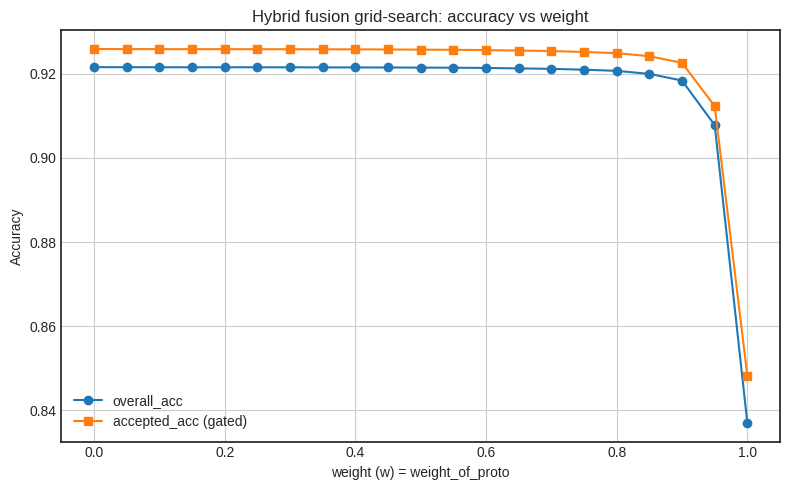

Grid search complete.
Best weight (w for proto): 0.0
Best metrics: {
  "weight": 0.0,
  "acc_overall": 0.9215318006275646,
  "f1_overall": 0.9216547487241126,
  "logloss": 0.2240971696874208,
  "coverage": 0.9798052940703195,
  "acc_accepted": 0.9258344966332731,
  "f1_accepted": 0.9247798922704705,
  "score": 0.9256505522798065
}
Saved grid results to: /home/vituser23/Downloads/ProtoNet_processed_40M/cell10_hybrid_grid_results.json
Saved best summary to: /home/vituser23/Downloads/ProtoNet_processed_40M/cell10_hybrid_best_summary.json
Saved accuracy plot to: /home/vituser23/Downloads/ProtoNet_processed_40M/cell10_hybrid_grid_plot.png


In [ ]:
# Cell 10 — Hybrid fusion

import os
import json
import time
import math
from collections import OrderedDict

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, log_loss

SAVE_DIR = "/home/vituser23/Downloads/ProtoNet_processed_40M"
EMB_TEST_PATH = os.path.join(SAVE_DIR, "proto_emb_test.npy")
FEATURES_PATH = os.path.join(SAVE_DIR, "features_resampled.npy")
TARGET_PATH   = os.path.join(SAVE_DIR, "target_resampled.npy")
MODEL_FUSION = os.path.join(SAVE_DIR, "euc_protodemon.pt")
MODEL_BASIC  = os.path.join(SAVE_DIR, "protodemon.pt")
CENTROID_FUSION = os.path.join(SAVE_DIR, "euc_final_centroids.pt")
XGB_MODEL_PATH = os.path.join(SAVE_DIR, "xgb_on_proto_embeddings.joblib")
XGB_META_PATH  = os.path.join(SAVE_DIR, "xgb_on_proto_meta.json")
REJ_JSON = os.path.join(SAVE_DIR, "rejection_thresholds.json")

OUT_JSON = os.path.join(SAVE_DIR, "cell10_hybrid_grid_results.json")
OUT_BEST  = os.path.join(SAVE_DIR, "cell10_hybrid_best_summary.json")
OUT_PLOT  = os.path.join(SAVE_DIR, "cell10_hybrid_grid_plot.png")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 2048
SEED = 42
GRID_WEIGHTS = np.linspace(0.0, 1.0, 21)
TARGET_COVERAGE = 0.98
np.random.seed(SEED)
torch.manual_seed(SEED)

def euclidean_distance_matrix(x, centroids):
    return torch.cdist(x, centroids)

def cosine_distance_matrix(x, centroids, eps=1e-8):
    x_norm = x / (x.norm(dim=1, keepdim=True) + eps)
    c_norm = centroids / (centroids.norm(dim=1, keepdim=True) + eps)
    sim = torch.matmul(x_norm, c_norm.t())
    return 1.0 - sim

def min_max_normalize_per_sample(dist_mat, eps=1e-8):
    min_vals = dist_mat.min(dim=1, keepdim=True)[0]
    max_vals = dist_mat.max(dim=1, keepdim=True)[0]
    return (dist_mat - min_vals) / (max_vals - min_vals + eps)

def proto_probs_from_embeddings(emb_torch, centroids_torch, alpha, batch_size=2048):
    N = emb_torch.size(0)
    all_probs = []
    all_dmin = []
    with torch.no_grad():
        for i in range(0, N, batch_size):
            xb = emb_torch[i:i+batch_size].to(centroids_torch.device)
            d_e = euclidean_distance_matrix(xb, centroids_torch)

            xb_norm = xb / (xb.norm(dim=1, keepdim=True) + 1e-8)
            cent_norm = centroids_torch / (centroids_torch.norm(dim=1, keepdim=True) + 1e-8)
            d_c = 1.0 - torch.matmul(xb_norm, cent_norm.t())
            d_e_norm = min_max_normalize_per_sample(d_e)
            d_c_norm = min_max_normalize_per_sample(d_c)
            d_fused = alpha * d_e_norm + (1.0 - alpha) * d_c_norm
            logits = -d_fused
            probs = F.softmax(logits, dim=1)
            pmax = probs.max(dim=1).values
            dmin = d_fused.min(dim=1).values
            all_probs.append(probs.cpu().numpy())
            all_dmin.append(dmin.cpu().numpy())
    Pproto = np.concatenate(all_probs, axis=0)
    dmin = np.concatenate(all_dmin, axis=0)
    proto_maxprob = Pproto.max(axis=1)
    return Pproto, dmin, proto_maxprob

def load_xgb_or_fallback(path_joblib, meta_path=None):
    clf = None
    xgb_booster = None
    meta = {}
    if os.path.exists(path_joblib):
        try:
            import joblib as _joblib
            clf = _joblib.load(path_joblib)

            try:
                import xgboost as xgb
                if isinstance(clf, xgb.Booster):
                    xgb_booster = clf
                    clf = None
            except Exception:
                if clf.__class__.__name__.lower().startswith("booster"):
                    xgb_booster = clf
                    clf = None
        except Exception:
            clf = None
    if meta_path and os.path.exists(meta_path):
        try:
            with open(meta_path, "r") as fh:
                meta = json.load(fh)
        except Exception:
            meta = {}
    return clf, xgb_booster, meta

def xgb_predict_proba_safe(booster, dmatrix, best_ntree_limit=None):

    try:
        if best_ntree_limit is not None:
            end_iter = int(best_ntree_limit)
            probs = booster.predict(dmatrix, iteration_range=(0, end_iter))
        else:
            probs = booster.predict(dmatrix)
    except TypeError:
        try:
            if best_ntree_limit is not None:
                probs = booster.predict(dmatrix, ntree_limit=int(best_ntree_limit))
            else:
                probs = booster.predict(dmatrix)
        except Exception:
            probs = booster.predict(dmatrix)
    return np.asarray(probs)

if not os.path.exists(CENTROID_FUSION):
    raise FileNotFoundError("Centroids not found (CENTROID_FUSION). Run earlier cells.")
centroids = torch.load(CENTROID_FUSION, map_location=DEVICE)
if not isinstance(centroids, torch.Tensor):
    centroids = torch.tensor(np.asarray(centroids), dtype=torch.float32)
centroids = centroids.to(DEVICE)
z_dim = centroids.shape[1]

alpha = 1.0
if os.path.exists(MODEL_FUSION):
    try:
        ck = torch.load(MODEL_FUSION, map_location='cpu')
        if isinstance(ck, dict):
            if 'alpha_param' in ck:
                alpha = float(torch.sigmoid(torch.tensor(ck['alpha_param'])).item())
            else:
                for key in ('model_state_dict','state_dict'):
                    if key in ck and isinstance(ck[key], dict):
                        for k,v in ck[key].items():
                            if 'alpha_param' in k:
                                alpha = float(torch.sigmoid(v).item())
                                break
                        if alpha != 1.0:
                            break
    except Exception:
        alpha = 1.0

tau_dist = None; p_thresh = None
if os.path.exists(REJ_JSON):
    try:
        with open(REJ_JSON, "r") as fh:
            rej = json.load(fh)
        tau_dist = float(rej['thresholds']['tau_dist'])
        p_thresh = float(rej['thresholds']['p_thresh'])
    except Exception:
        tau_dist = None; p_thresh = None


if os.path.exists(EMB_TEST_PATH):
    emb_test = np.load(EMB_TEST_PATH).astype(np.float32)
    print("Loaded precomputed test embeddings:", EMB_TEST_PATH, "shape=", emb_test.shape)

    if os.path.exists(TARGET_PATH):
        y_all = np.load(TARGET_PATH).astype(np.int64)

        from sklearn.model_selection import train_test_split
        X_dummy = np.zeros((y_all.shape[0],1), dtype=np.float32)
        X_temp_idx, X_test_idx, y_temp_idx, y_test = train_test_split(X_dummy, y_all, test_size=0.2, random_state=SEED, stratify=y_all)

        y_test = np.asarray(y_test, dtype=np.int64)
    else:
        raise FileNotFoundError("TARGET_PATH missing; required to obtain test labels when embeddings are precomputed.")
    emb_test_t = torch.from_numpy(emb_test).to(DEVICE)
else:
    if not (os.path.exists(FEATURES_PATH) and os.path.exists(TARGET_PATH)):
        raise FileNotFoundError("No test embeddings and no features/targets to compute them.")
    X_all = np.load(FEATURES_PATH).astype(np.float32)
    y_all = np.load(TARGET_PATH).astype(np.int64)
    from sklearn.model_selection import train_test_split
    X_temp, X_test_np, y_temp, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all)

    import torch.nn as nn
    class ProtoNetV2_local(nn.Module):
        def __init__(self, input_dim, hid_dim=256, z_dim=128, dropout=0.5):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, hid_dim),
                nn.ReLU(inplace=True),
                nn.BatchNorm1d(hid_dim),
                nn.Dropout(dropout),
                nn.Linear(hid_dim, hid_dim // 2),
                nn.ReLU(inplace=True),
                nn.BatchNorm1d(hid_dim // 2),
                nn.Dropout(dropout),
                nn.Linear(hid_dim // 2, z_dim)
            )
        def forward(self, x): return self.encoder(x)
    class FusionProtoNet_local(nn.Module):
        def __init__(self, input_dim, hid_dim=256, z_dim=128, dropout=0.5, init_alpha_logit=0.8473):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, hid_dim),
                nn.LeakyReLU(inplace=True),
                nn.BatchNorm1d(hid_dim),
                nn.Dropout(dropout),
                nn.Linear(hid_dim, hid_dim // 2),
                nn.LeakyReLU(inplace=True),
                nn.BatchNorm1d(hid_dim // 2),
                nn.Dropout(dropout),
                nn.Linear(hid_dim // 2, z_dim)
            )
            self.alpha_param = nn.Parameter(torch.tensor(init_alpha_logit, dtype=torch.float32))
        def forward(self, x): return self.encoder(x)
    input_dim = X_all.shape[1]
    if os.path.exists(MODEL_FUSION):
        model_local = FusionProtoNet_local(input_dim=input_dim, hid_dim=256, z_dim=z_dim).to(DEVICE)
    elif os.path.exists(MODEL_BASIC):
        model_local = ProtoNetV2_local(input_dim=input_dim, hid_dim=256, z_dim=z_dim).to(DEVICE)
    else:
        raise FileNotFoundError("No encoder checkpoint found to compute embeddings.")

    ck = torch.load(MODEL_FUSION if os.path.exists(MODEL_FUSION) else MODEL_BASIC, map_location='cpu')
    if isinstance(ck, dict):
        st = ck.get('model_state_dict', ck.get('state_dict', ck))
    else:
        st = ck
    new_st = {}
    model_keys = set(model_local.state_dict().keys())
    for k,v in st.items():
        kk = k[7:] if k.startswith("module.") and k[7:] in model_keys else k
        if kk in model_keys:
            new_st[kk] = v
    model_local.load_state_dict(new_st, strict=False)
    model_local.eval()
    def compute_embs_np(X_np, model, batch_size=2048):
        embs = []
        with torch.no_grad():
            for i in range(0, X_np.shape[0], batch_size):
                xb = torch.from_numpy(X_np[i:i+batch_size].astype(np.float32)).to(DEVICE)
                e = model(xb).cpu()
                embs.append(e)
        return torch.cat(embs, dim=0).to(DEVICE)
    emb_test_t = compute_embs_np(X_test_np, model_local, BATCH_SIZE)
    y_test = np.asarray(y_test, dtype=np.int64)
    print("Computed test embeddings from checkpoint. shape:", emb_test_t.shape)

print("Computing ProtoNet posterior probabilities on test set...")
Pproto_test, dmin_test, proto_pmax_test = proto_probs_from_embeddings(emb_test_t, centroids, alpha, batch_size=BATCH_SIZE)
num_classes = Pproto_test.shape[1]

clf, bst, xgb_meta = load_xgb_or_fallback(XGB_MODEL_PATH, XGB_META_PATH)
P_xgb = None
if bst is not None:

    try:
        import xgboost as xgb
        dtest = xgb.DMatrix(emb_test if 'emb_test' in globals() else emb_test_t.cpu().numpy())
        best_ntree_limit = xgb_meta.get('best_ntree_limit', None)
        P_xgb = xgb_predict_proba_safe(bst, dtest, best_ntree_limit)
    except Exception:

        try:
            import xgboost as xgb
            dtest = xgb.DMatrix(emb_test if 'emb_test' in globals() else emb_test_t.cpu().numpy())
            P_xgb = bst.predict(dtest)
        except Exception:
            raise RuntimeError("Failed to predict with loaded xgboost booster.")
elif clf is not None:

    try:
        P_xgb = clf.predict_proba(emb_test if 'emb_test' in globals() else emb_test_t.cpu().numpy())
    except Exception:

        try:
            dec = clf.decision_function(emb_test if 'emb_test' in globals() else emb_test_t.cpu().numpy())

            ex = np.exp(dec - np.max(dec, axis=1, keepdims=True))
            P_xgb = ex / ex.sum(axis=1, keepdims=True)
        except Exception:
            raise RuntimeError("Loaded classifier cannot provide probabilities.")
else:
    raise FileNotFoundError("No classifier (XGBoost or fallback) found at expected path.")


P_xgb = np.asarray(P_xgb)
if P_xgb.ndim == 1:

    P_xgb = P_xgb.reshape(-1, 1)
if P_xgb.shape[1] != num_classes:

    if P_xgb.shape[0] == num_classes and P_xgb.shape[1] == Pproto_test.shape[0]:
        P_xgb = P_xgb.T
    else:

        raise RuntimeError(f"Classifier probs shape {P_xgb.shape} incompatible with proto classes {num_classes}.")


preds_proto = Pproto_test.argmax(axis=1)
preds_xgb = P_xgb.argmax(axis=1)

if tau_dist is None or p_thresh is None:
    print("Warning: gating thresholds (tau_dist, p_thresh) not found. Gating will be skipped in accepted-subset metrics.")
    gating_available = False
else:
    gating_available = True
    accepted_mask_proto_based = (dmin_test <= tau_dist) & (proto_pmax_test >= p_thresh)
    coverage_proto = float(accepted_mask_proto_based.mean())
    print(f"Gating available. Test coverage under proto thresholds: {coverage_proto:.4f} (tau={tau_dist:.6g}, p_thresh={p_thresh:.6g})")

results = []
best_conf = {'weight': None, 'score': -1.0, 'metrics': None}

for w in GRID_WEIGHTS:
    P_fused = w * Pproto_test + (1.0 - w) * P_xgb
    preds_fused = P_fused.argmax(axis=1)

    acc_overall = float(accuracy_score(y_test, preds_fused))
    f1_overall = float(f1_score(y_test, preds_fused, average='macro'))

    eps = 1e-12
    try:
        ll = float(log_loss(y_test, np.clip(P_fused, eps, 1.0 - eps)))
    except Exception:
        ll = float('nan')

    if gating_available:
        mask = accepted_mask_proto_based.copy()
        accepted_idx = np.where(mask)[0]
        coverage = float(mask.mean())
        if mask.sum() > 0:
            acc_accept = float((preds_fused[mask] == y_test[mask]).mean())
            f1_accept = float(f1_score(y_test[mask], preds_fused[mask], average='macro'))
        else:
            acc_accept = float('nan'); f1_accept = float('nan')
    else:
        coverage = float('nan'); acc_accept = float('nan'); f1_accept = float('nan')

    if gating_available:
        meets_cov = coverage >= TARGET_COVERAGE
        if meets_cov:
            score = acc_accept + 0.01 * coverage
        else:
            score = acc_accept * (coverage / TARGET_COVERAGE)
    else:
        score = acc_overall

    row = {
        'weight': float(w),
        'acc_overall': acc_overall,
        'f1_overall': f1_overall,
        'logloss': ll,
        'coverage': coverage,
        'acc_accepted': acc_accept,
        'f1_accepted': f1_accept,
        'score': float(score)
    }
    results.append(row)

    if score > best_conf['score']:
        best_conf['weight'] = float(w)
        best_conf['score'] = float(score)
        best_conf['metrics'] = row.copy()

out_obj = {
    'created_at': time.strftime("%Y-%m-%d %H:%M:%S", time.localtime()),
    'alpha_proto_centroids': float(alpha),
    'tau_dist': None if tau_dist is None else float(tau_dist),
    'p_thresh': None if p_thresh is None else float(p_thresh),
    'target_coverage_preference': float(TARGET_COVERAGE),
    'grid_results': results
}
with open(OUT_JSON, "w") as fh:
    json.dump(out_obj, fh, indent=2)

ws = np.array([r['weight'] for r in results])
accs_overall = np.array([r['acc_overall'] for r in results])
acc_accepts = np.array([np.nan_to_num(r['acc_accepted'], nan=np.nan) for r in results])
f1_overall = np.array([r['f1_overall'] for r in results])

fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(ws, accs_overall, marker='o', label='overall_acc')
if not np.all(np.isnan(acc_accepts)):
    ax1.plot(ws, acc_accepts, marker='s', label='accepted_acc (gated)')
ax1.set_xlabel("weight (w) = weight_of_proto")
ax1.set_ylabel("Accuracy")
ax1.set_title("Hybrid fusion grid-search: accuracy vs weight")
ax1.grid(True)
ax1.legend(loc='best')
plt.tight_layout()
plt.savefig(OUT_PLOT, dpi=180)
plt.show()

best_summary = {
    'best_weight': best_conf['weight'],
    'best_score': best_conf['score'],
    'best_metrics': best_conf['metrics'],
    'note': "Score heuristic prioritizes accepted accuracy when gating available; otherwise overall accuracy."
}
with open(OUT_BEST, "w") as fh:
    json.dump(best_summary, fh, indent=2)

print("Grid search complete.")
print("Best weight (w for proto):", best_conf['weight'])
print("Best metrics:", json.dumps(best_conf['metrics'], indent=2))
print("Saved grid results to:", OUT_JSON)
print("Saved best summary to:", OUT_BEST)
print("Saved accuracy plot to:", OUT_PLOT)


In [ ]:

# Cell 11 — Final Prediction Layer

import os
import json
import time
import math
from collections import OrderedDict, defaultdict

import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score

SAVE_DIR = "/home/vituser23/Downloads/ProtoNet_processed_40M"
CENTROID_FUSION = os.path.join(SAVE_DIR, "euc_final_centroids.pt")
MODEL_FUSION = os.path.join(SAVE_DIR, "euc_protodemon.pt")
MODEL_BASIC  = os.path.join(SAVE_DIR, "protodemon.pt")
REJ_JSON     = os.path.join(SAVE_DIR, "rejection_thresholds.json")
XGB_MODEL_JOBLIB = os.path.join(SAVE_DIR, "xgb_on_proto_embeddings.joblib")
XGB_META_PATH    = os.path.join(SAVE_DIR, "xgb_on_proto_meta.json")
EMB_TEST_PATH    = os.path.join(SAVE_DIR, "proto_emb_test.npy")
FEATURES_PATH    = os.path.join(SAVE_DIR, "features_resampled.npy")
TARGET_PATH      = os.path.join(SAVE_DIR, "target_resampled.npy")
LABEL_MAP_PATH   = os.path.join(SAVE_DIR, "label_mapping.json")

OUT_PRED_CSV = os.path.join(SAVE_DIR, "cell11_predictions_with_tiers.csv")
OUT_EXPL_JSON = os.path.join(SAVE_DIR, "cell11_predictions_explanations.json")
OUT_SUMMARY = os.path.join(SAVE_DIR, "cell11_summary.json")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 2048
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

def euclidean_distance_matrix(x, centroids):
    return torch.cdist(x, centroids)

def cosine_distance_matrix(x, centroids, eps=1e-8):
    x_norm = x / (x.norm(dim=1, keepdim=True) + eps)
    c_norm = centroids / (centroids.norm(dim=1, keepdim=True) + eps)
    sim = torch.matmul(x_norm, c_norm.t())
    return 1.0 - sim

def min_max_normalize_per_sample(dist_mat, eps=1e-8):
    min_vals = dist_mat.min(dim=1, keepdim=True)[0]
    max_vals = dist_mat.max(dim=1, keepdim=True)[0]
    return (dist_mat - min_vals) / (max_vals - min_vals + eps)

def proto_probs_from_embeddings(emb_torch, centroids_torch, alpha, batch_size=2048):
    """
    Returns:
      Pproto (N, C) numpy, dmin (N,), proto_maxprob (N,), proto_preds (N,)
    """
    N = emb_torch.size(0)
    all_probs = []
    all_dmin = []
    with torch.no_grad():
        for i in range(0, N, batch_size):
            xb = emb_torch[i:i+batch_size].to(centroids_torch.device)
            d_e = euclidean_distance_matrix(xb, centroids_torch)

            xb_norm = xb / (xb.norm(dim=1, keepdim=True) + 1e-8)
            cent_norm = centroids_torch / (centroids_torch.norm(dim=1, keepdim=True) + 1e-8)
            d_c = 1.0 - torch.matmul(xb_norm, cent_norm.t())
            d_e_norm = min_max_normalize_per_sample(d_e)
            d_c_norm = min_max_normalize_per_sample(d_c)
            d_fused = alpha * d_e_norm + (1.0 - alpha) * d_c_norm
            logits = -d_fused
            probs = F.softmax(logits, dim=1)
            dmin = d_fused.min(dim=1).values
            all_probs.append(probs.cpu().numpy())
            all_dmin.append(dmin.cpu().numpy())
    Pproto = np.concatenate(all_probs, axis=0)
    dmin = np.concatenate(all_dmin, axis=0)
    proto_maxprob = Pproto.max(axis=1)
    proto_preds = Pproto.argmax(axis=1)
    return Pproto, dmin, proto_maxprob, proto_preds

def load_classifier_joblib(path_joblib, meta_path=None):
    clf = None
    booster = None
    meta = {}
    if os.path.exists(path_joblib):
        try:
            import joblib as _joblib
            obj = _joblib.load(path_joblib)

            try:
                import xgboost as xgb
                if isinstance(obj, xgb.Booster):
                    booster = obj
                else:
                    clf = obj
            except Exception:
                if obj.__class__.__name__.lower().startswith("booster"):
                    booster = obj
                else:
                    clf = obj
        except Exception as e:
            raise RuntimeError(f"Failed to load classifier joblib: {e}")

    if meta_path and os.path.exists(meta_path):
        try:
            with open(meta_path, "r") as fh:
                meta = json.load(fh)
        except Exception:
            meta = {}
    return clf, booster, meta

def xgb_predict_proba_safe(booster, data_np, best_ntree_limit=None):
    """
    Accepts either Booster object; data_np is (N, D) numpy
    Returns (N, C) probs
    """
    try:
        import xgboost as xgb
        dmat = xgb.DMatrix(data_np)
        try:
            if best_ntree_limit is not None:
                probs = booster.predict(dmat, iteration_range=(0, int(best_ntree_limit)))
            else:
                probs = booster.predict(dmat)
        except TypeError:

            if best_ntree_limit is not None:
                probs = booster.predict(dmat, ntree_limit=int(best_ntree_limit))
            else:
                probs = booster.predict(dmat)
        return np.asarray(probs)
    except Exception as e:
        raise RuntimeError(f"xgboost predict failed: {e}")

if not os.path.exists(CENTROID_FUSION):
    raise FileNotFoundError("Centroids file not found; run earlier cells to produce euc_final_centroids.pt")

centroids = torch.load(CENTROID_FUSION, map_location=DEVICE)
if not isinstance(centroids, torch.Tensor):
    centroids = torch.tensor(np.asarray(centroids), dtype=torch.float32)
centroids = centroids.to(DEVICE)

alpha = 1.0
if os.path.exists(MODEL_FUSION):
    try:
        ck = torch.load(MODEL_FUSION, map_location='cpu')
        if isinstance(ck, dict):
            if 'alpha_param' in ck:
                alpha = float(torch.sigmoid(torch.tensor(ck['alpha_param'])).item())
            else:
                for key in ('model_state_dict','state_dict'):
                    if key in ck and isinstance(ck[key], dict):
                        for k,v in ck[key].items():
                            if 'alpha_param' in k:
                                alpha = float(torch.sigmoid(v).item()); break
                        if alpha != 1.0: break
    except Exception:
        alpha = 1.0

tau_dist = None
p_thresh = None
if os.path.exists(REJ_JSON):
    try:
        with open(REJ_JSON, "r") as fh:
            rej = json.load(fh)
        tau_dist = float(rej['thresholds']['tau_dist'])
        p_thresh = float(rej['thresholds']['p_thresh'])
    except Exception:
        tau_dist = None; p_thresh = None

print(f"Loaded centroids (shape={tuple(centroids.shape)}) alpha={alpha} gating tau={tau_dist} p_thresh={p_thresh}")

clf, xgb_booster, xgb_meta = load_classifier_joblib(XGB_MODEL_JOBLIB, XGB_META_PATH)
print("Classifier loaded:", "xgb_booster" if xgb_booster is not None else ("sklearn estimator" if clf is not None else "NONE"))

if clf is None and xgb_booster is None:
    raise FileNotFoundError("No classifier available (xgboost or sklearn). Run Cell 9 to train classifier.")

import torch.nn as nn
class ProtoNetV2_local(nn.Module):
    def __init__(self, input_dim, hid_dim=256, z_dim=centroids.shape[1], dropout=0.5, use_leaky=False):
        super().__init__()
        act = nn.LeakyReLU(inplace=True) if use_leaky else nn.ReLU(inplace=True)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hid_dim),
            act,
            nn.BatchNorm1d(hid_dim),
            nn.Dropout(dropout),
            nn.Linear(hid_dim, hid_dim//2),
            act,
            nn.BatchNorm1d(hid_dim//2),
            nn.Dropout(dropout),
            nn.Linear(hid_dim//2, z_dim)
        )
    def forward(self, x): return self.encoder(x)

if os.path.exists(EMB_TEST_PATH):
    emb_test_np = np.load(EMB_TEST_PATH).astype(np.float32)
    emb_test_torch = torch.from_numpy(emb_test_np).to(DEVICE)
    if os.path.exists(TARGET_PATH):
        y_all = np.load(TARGET_PATH).astype(np.int64)
        from sklearn.model_selection import train_test_split
        X_dummy = np.zeros((y_all.shape[0],1), dtype=np.float32)
        _, _, _, y_test = train_test_split(X_dummy, y_all, test_size=0.2, random_state=SEED, stratify=y_all)
        y_test = np.asarray(y_test, dtype=np.int64)
    else:
        y_test = None
    print("Using precomputed embeddings:", emb_test_np.shape)
else:
    if not (os.path.exists(FEATURES_PATH) and os.path.exists(TARGET_PATH)):
        raise FileNotFoundError("No precomputed embeddings and missing features/targets to compute embeddings.")
    X_all = np.load(FEATURES_PATH).astype(np.float32)
    y_all = np.load(TARGET_PATH).astype(np.int64)
    from sklearn.model_selection import train_test_split
    X_temp, X_test_np, y_temp, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all)

    input_dim = X_all.shape[1]
    ckpt_path = MODEL_FUSION if os.path.exists(MODEL_FUSION) else (MODEL_BASIC if os.path.exists(MODEL_BASIC) else None)
    model_local = ProtoNetV2_local(input_dim=input_dim, hid_dim=256, z_dim=centroids.shape[1], use_leaky=True).to(DEVICE)
    if ckpt_path is None:
        print("Warning: No encoder checkpoint found. Embeddings will be random-initialized (NOT recommended).")
    else:
        ck = torch.load(ckpt_path, map_location='cpu')
        st = ck.get('model_state_dict', ck.get('state_dict', ck)) if isinstance(ck, dict) else ck
        new_st = {}
        keys = set(model_local.state_dict().keys())
        for k,v in st.items():
            kk = k[7:] if k.startswith("module.") and k[7:] in keys else k
            if kk in keys:
                new_st[kk] = v
        model_local.load_state_dict(new_st, strict=False)
        print("Loaded encoder weights from:", ckpt_path)
    model_local.eval()

    def compute_embs_np(X_np, model, batch_size=2048):
        embs = []
        with torch.no_grad():
            for i in range(0, X_np.shape[0], batch_size):
                xb = torch.from_numpy(X_np[i:i+batch_size].astype(np.float32)).to(DEVICE)
                e = model(xb).cpu()
                embs.append(e)
        return torch.cat(embs, dim=0).to(DEVICE)

    emb_test_torch = compute_embs_np(X_test_np, model_local, batch_size=BATCH_SIZE)
    print("Computed test embeddings shape:", tuple(emb_test_torch.shape))

Pproto_test, dmin_test, proto_pmax_test, proto_preds_test = proto_probs_from_embeddings(emb_test_torch, centroids, float(alpha), batch_size=BATCH_SIZE)
num_classes = Pproto_test.shape[1]

if xgb_booster is not None:
    best_nt = xgb_meta.get('best_ntree_limit', None)
    if best_nt is None and isinstance(xgb_meta.get('best_ntree_limit', None), (int, float)):
        best_nt = xgb_meta.get('best_ntree_limit')

    emb_for_clf = emb_test_np if 'emb_test_np' in globals() else (emb_test_torch.cpu().numpy())
    P_xgb = xgb_predict_proba_safe(xgb_booster, emb_for_clf, best_ntree_limit=best_nt)
else:
    emb_for_clf = emb_test_np if 'emb_test_np' in globals() else (emb_test_torch.cpu().numpy())
    try:
        P_xgb = clf.predict_proba(emb_for_clf)
    except Exception:
        dec = clf.decision_function(emb_for_clf)
        ex = np.exp(dec - np.max(dec, axis=1, keepdims=True))
        P_xgb = ex / ex.sum(axis=1, keepdims=True)

P_xgb = np.asarray(P_xgb)
if P_xgb.ndim == 1:
    P_xgb = P_xgb.reshape(-1, 1)
if P_xgb.shape[1] != num_classes:
    if P_xgb.shape[0] == num_classes and P_xgb.shape[1] == Pproto_test.shape[0]:
        P_xgb = P_xgb.T
    else:
        raise RuntimeError(f"Classifier probs shape mismatch: {P_xgb.shape} vs proto classes {num_classes}")

preds_xgb = P_xgb.argmax(axis=1)
xgb_conf = P_xgb.max(axis=1)

TIER_A_CONF = 0.90
TIER_B_CONF = 0.60
def assign_tier(is_accepted, xgb_conf_val):
    if not is_accepted:
        return "OOD/REJECT"
    if xgb_conf_val >= TIER_A_CONF:
        return "Tier A - Auto"
    if xgb_conf_val >= TIER_B_CONF:
        return "Tier B - Auto+Explain"
    return "Tier C - Review"

def topk_proto_info(emb_vec_torch, centroids_torch, k=3):
    if emb_vec_torch.dim() == 1:
        emb = emb_vec_torch.unsqueeze(0)
    else:
        emb = emb_vec_torch
    d_e = euclidean_distance_matrix(emb, centroids_torch)
    d_c = cosine_distance_matrix(emb, centroids_torch)
    d_e_norm = min_max_normalize_per_sample(d_e)
    d_c_norm = min_max_normalize_per_sample(d_c)
    d_fused = float(alpha) * d_e_norm + (1.0 - float(alpha)) * d_c_norm
    dvals = d_fused.squeeze(0).cpu().numpy()
    top_idxs = np.argsort(dvals)[:k]
    return [{"centroid_idx": int(int(i)), "dmin_fused": float(dvals[int(i)])} for i in top_idxs]

feature_names = None
if os.path.exists(LABEL_MAP_PATH):
    try:
        pass
    except Exception:
        pass

use_shap = False
shap_explainer = None
try:
    import shap
    if xgb_booster is not None:
        try:
            shap_explainer = shap.TreeExplainer(xgb_booster)
            use_shap = True
        except Exception:
            use_shap = False
    elif clf is not None:
        try:
            shap_explainer = shap.TreeExplainer(clf)
            use_shap = True
        except Exception:
            use_shap = False
except Exception:
    use_shap = False

fallback_feature_importances = None
if not use_shap and clf is not None:
    try:
        if hasattr(clf, "feature_importances_"):
            fallback_feature_importances = clf.feature_importances_
        elif hasattr(clf, "coef_"):
            fallback_feature_importances = np.mean(np.abs(clf.coef_), axis=0)
    except Exception:
        fallback_feature_importances = None

def explain_batch(start_idx, end_idx, emb_torch, raw_features_np=None, topk=3):

    expls = []
    if use_shap and shap_explainer is not None and raw_features_np is not None:
        try:
            shap_vals = shap_explainer.shap_values(raw_features_np[start_idx:end_idx])

        except Exception:
            shap_vals = None
    else:
        shap_vals = None

    for idx in range(start_idx, end_idx):

        emb_vec = emb_torch[idx].to(centroids.device)
        proto_topk = topk_proto_info(emb_vec, centroids, k=topk)

        topkl = list(np.argsort(P_xgb[idx])[::-1][:topk])
        topk_probs = [(int(int(c)), float(P_xgb[idx][c])) for c in topkl]

        feats = []
        if shap_vals is not None and raw_features_np is not None:
            try:
                if isinstance(shap_vals, list):
                    abs_sum = np.sum([np.abs(s[idx - start_idx]) for s in shap_vals], axis=0)
                else:
                    abs_sum = np.abs(shap_vals[idx - start_idx])
                top_features_idx = np.argsort(abs_sum)[::-1][:topk]
                feats = [{"feat_idx": int(int(fi)), "score": float(abs_sum[fi])} for fi in top_features_idx]
            except Exception:
                feats = []
        elif fallback_feature_importances is not None:
            top_features_idx = np.argsort(fallback_feature_importances)[::-1][:topk]
            feats = [{"feat_idx": int(int(fi)), "score": float(fallback_feature_importances[fi])} for fi in top_features_idx]
        else:
            feats = []

        expl = {
            "index": int(idx),
            "proto": {
                "dmin": float(dmin_test[idx]),
                "proto_pmax": float(proto_pmax_test[idx]),
                "proto_pred": int(int(proto_preds_test[idx])),
                "proto_topk_centroids": proto_topk
            },
            "xgb": {
                "xgb_pred": int(int(preds_xgb[idx])),
                "xgb_conf": float(xgb_conf[idx]),
                "xgb_topk": [{"class": int(int(c)), "prob": float(P_xgb[idx][c])} for c in topkl]
            },
            "feature_attributions": feats
        }
        expls.append(expl)
    return expls

N = Pproto_test.shape[0]
rows = []
raw_features = None
if os.path.exists(FEATURES_PATH):
    try:
        X_all = np.load(FEATURES_PATH).astype(np.float32)
        from sklearn.model_selection import train_test_split
        X_dummy = np.zeros((y_all.shape[0],1), dtype=np.float32) if 'y_all' in globals() else np.zeros((X_all.shape[0],1), dtype=np.float32)

        _, X_test_np, _, y_test_tmp = train_test_split(X_dummy, np.load(TARGET_PATH).astype(np.int64), test_size=0.2, random_state=SEED, stratify=np.load(TARGET_PATH))

        raw_features = None
    except Exception:
        raw_features = None

if tau_dist is not None and p_thresh is not None:
    accepted_mask = (dmin_test <= float(tau_dist)) & (proto_pmax_test >= float(p_thresh))
else:
    accepted_mask = np.ones(N, dtype=bool)

for i in range(N):
    is_accepted = bool(bool(accepted_mask[i]))
    tier = assign_tier(is_accepted, float(xgb_conf[i]))
    proto_pred = int(int(proto_preds_test[i]))
    xgb_pred = int(int(preds_xgb[i]))
    row = {
        "index": int(i),
        "proto_pred": proto_pred,
        "proto_pmax": float(proto_pmax_test[i]),
        "dmin": float(dmin_test[i]),
        "xgb_pred": xgb_pred,
        "xgb_conf": float(xgb_conf[i]),
        "final_pred": int(xgb_pred),
        "is_accepted_proto_gating": bool(is_accepted),
        "tier": tier
    }
    rows.append(row)

df_out = pd.DataFrame(rows)
df_out.to_csv(OUT_PRED_CSV, index=False)
print("Saved predictions + tiers to:", OUT_PRED_CSV)

final_accuracy = None
accepted_accuracy = None
if 'y_test' in globals() and y_test is not None:
    try:
        final_preds = df_out['final_pred'].values
        final_accuracy = float(accuracy_score(y_test, final_preds))
    except Exception:
        final_accuracy = None

    if tau_dist is not None and p_thresh is not None:
        try:
            mask = accepted_mask
            if mask.sum() > 0:
                accepted_accuracy = float(accuracy_score(np.asarray(y_test)[mask], final_preds[mask]))
            else:
                accepted_accuracy = None
        except Exception:
            accepted_accuracy = None

EXPL_BATCH = 5000
explanations = []
for start in range(0, N, EXPL_BATCH):
    end = min(N, start+EXPL_BATCH)
    expl_batch = explain_batch(start, end, emb_test_torch, raw_features_np=None, topk=3)
    explanations.extend(expl_batch)
with open(OUT_EXPL_JSON, "w") as fh:
    json.dump({"created_at": time.strftime("%Y-%m-%d %H:%M:%S"), "explanations": explanations}, fh)
print("Saved explanations (best-effort) to:", OUT_EXPL_JSON)

summary = {
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    "n_samples": int(N),
    "gating_available": bool(tau_dist is not None and p_thresh is not None),
    "tau_dist": float(tau_dist) if tau_dist is not None else None,
    "p_thresh": float(p_thresh) if p_thresh is not None else None,
    "tier_thresholds": {"tier_a_conf": TIER_A_CONF, "tier_b_conf": TIER_B_CONF},
    "classifier_type": ("xgboost_booster" if xgb_booster is not None else "sklearn_estimator"),
    "final_accuracy_overall": final_accuracy,
    "final_accuracy_on_accepted": accepted_accuracy
}
with open(OUT_SUMMARY, "w") as fh:
    json.dump(summary, fh, indent=2)
print("Saved summary to:", OUT_SUMMARY)

from collections import Counter
tier_counts = Counter(df_out['tier'].values)
print("\nCell 11 — Final Prediction Layer summary")
print("Total samples:", N)
print("Tier distribution:", dict(tier_counts))
if tau_dist is not None:
    coverage = float(accepted_mask.mean())
    print(f"Gating coverage (proto): {coverage:.4f} (tau_dist={tau_dist}, p_thresh={p_thresh})")

if final_accuracy is not None:
    print(f"Final overall accuracy (production final_pred vs y_test): {final_accuracy:.4f}")
else:
    print("Final overall accuracy: N/A (no y_test available)")
if accepted_accuracy is not None:
    print(f"Final accepted-subset accuracy (on gating-accepted samples): {accepted_accuracy:.4f}")
else:
    print("Final accepted-subset accuracy: N/A (gating not available or no labels)")

print("Top classifier preds sample counts (first 10 classes):")
print(df_out['final_pred'].value_counts().head(10).to_dict())
print("\nDone — predictions + tiers + explanations persisted. Use OUT_PRED_CSV and OUT_EXPL_JSON for downstream audit and triage.")


/tmp/ipykernel_4062181/2567220431.py:161: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  alpha = float(torch.sigmoid(torch.tensor(ck['alpha_param'])).item())


Loaded centroids (shape=(20, 128)) alpha=3.618338450905867e-05 gating tau=3.618338450905867e-05 p_thresh=0.10542055070400239
Classifier loaded: xgb_booster
Using precomputed embeddings: (397728, 128)
Saved predictions + tiers to: /home/vituser23/Downloads/ProtoNet_processed_40M/cell11_predictions_with_tiers.csv
Saved explanations (best-effort) to: /home/vituser23/Downloads/ProtoNet_processed_40M/cell11_predictions_explanations.json
Saved summary to: /home/vituser23/Downloads/ProtoNet_processed_40M/cell11_summary.json

Cell 11 — Final Prediction Layer summary
Total samples: 397728
Tier distribution: {'Tier A - Auto': 297876, 'Tier B - Auto+Explain': 73346, 'Tier C - Review': 18474, 'OOD/REJECT': 8032}
Gating coverage (proto): 0.9798 (tau_dist=3.618338450905867e-05, p_thresh=0.10542055070400239)
Final overall accuracy (production final_pred vs y_test): 0.9215
Final accepted-subset accuracy (on gating-accepted samples): 0.9258
Top classifier preds sample counts (first 10 classes):
{0: 270